## Importando bibliotecas

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv
import numpy as np
import time
import re
from pathlib import Path
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

## Funcões:

In [3]:
def calcular_media_steps(df, nc_value):
    """
    Função que calcula a média e o desvio padrão dos steps para um dado dataframe e um valor específico de NC.
    """
    mean_steps = df['steps'].mean()  # Supondo que a coluna dos passos seja 'steps'
    std_steps = df['steps'].std()    # Desvio padrão dos passos
    return nc_value, mean_steps, std_steps

def plotar_media_steps_com_erro(dfs_list, nc_values, labels, 
                                title, xlabel, ylabel, 
                                x_log=True, y_log=True, 
                                x_min=None, x_max=None, 
                                y_min=None, y_max=None,
                                save_path=None):
    """
    Gera um gráfico de médias de steps com barras de erro para diferentes listas de dataframes organizadas por valores de 'O'.

    Parameters:
    - dfs_list: lista de listas de dataframes, onde cada sub-lista representa um valor de 'O'.
    - nc_values: lista com valores de NC correspondentes a cada sub-lista de dataframes.
    - labels: lista de rótulos para cada sub-lista de dataframes (valores de 'O').
    - title: título do gráfico.
    - xlabel: rótulo do eixo x.
    - ylabel: rótulo do eixo y.
    - x_log: define se o eixo x será em escala logarítmica (True por padrão).
    - y_log: define se o eixo y será em escala logarítmica (True por padrão).
    - x_min, x_max: limites inferior e superior para o eixo x.
    - y_min, y_max: limites inferior e superior para o eixo y.
    - save_path: caminho para salvar o gráfico (opcional).
    """

    plt.figure(figsize=(8, 6))

    for dfs, nc_value, label in zip(dfs_list, nc_values, labels):
        # Calcular as médias e desvios para cada dataframe na lista de dataframes específica
        nc_vals = []
        means = []
        std_devs = []
        
        for df, n in zip(dfs, nc_value):
            nc, mean, std = calcular_media_steps(df, n)
            nc_vals.append(nc)
            means.append(mean)
            std_devs.append(std)

        # Gerar o gráfico com erro
        plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5)

    if x_log:
        plt.xscale('log')
    if y_log:
        plt.yscale('log')

    # Definir os limites dos eixos, se fornecidos
    if x_min is not None and x_max is not None:
        plt.xlim(x_min, x_max)
    if y_min is not None and y_max is not None:
        plt.ylim(y_min, y_max)

    plt.legend()
    plt.tick_params(axis='both', which='major', labelsize=16)
    plt.title(title, fontsize=18)
    plt.xlabel(xlabel, fontsize=18)
    plt.ylabel(ylabel, fontsize=18)
    plt.grid(True)

    if save_path:
        plt.savefig(save_path)
        
    plt.show()


## Dados

### TCC = 0.95 e TCT = 0.95.
- Raio de procura 5.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [4]:
# O = 00
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_095" / "Distribuição_quadrada"/ "SR_5"
df_NP01_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/"NC_500_NE_1_O_0_TCC_0.95_TCT_0.95_SR_5.dat", delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# O = 2
df_NP01_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.95.
- Raio de procura 10.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [5]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_095" / "Distribuição_quadrada"/ "SR_10"
df_NP01_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')

df_NP01_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')

df_NP01_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')

# # O = 6
df_NP01_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')

# # O = 21
df_NP01_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')

# # O = 26
df_NP01_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.95.
- Raio de procura 20.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [6]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_095" / "Distribuição_quadrada"/ "SR_20"
# O = 00
df_NP01_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
# O = 02
df_NP01_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')

# O = 11
df_NP01_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.95.
- Raio de procura 30.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [7]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_095" / "Distribuição_quadrada"/ "SR_30"
# O = 00
df_NP01_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# O = 02
df_NP01_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.95.
- Raio de procura 40.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [8]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_095" / "Distribuição_quadrada"/ "SR_40"
# O = 00
df_NP01_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# O = 02
df_NP01_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# # O = 2s
df_NP01_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.95.
- Raio de procura 50.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [9]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_095" / "Distribuição_quadrada"/ "SR_50"
# O = 0
df_NP01_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# O = 02
df_NP01_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# # O =6
df_NP01_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# # O = 2
df_NP01_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.05.
- Raio de procura 5.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [10]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_5"
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.05.
- Raio de procura 10.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [11]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_10"
#O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.05.
- Raio de procura 20.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [12]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_20"
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.05.
- Raio de procura 30.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [13]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_30"
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.05.
- Raio de procura 40.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [14]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_40"
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.05.
- Raio de procura 50.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [15]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_50"
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.05.
- Raio de procura 5.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [16]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_5"
# O = 00
df_NP01_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

# O = 3
df_NP01_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP01_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP01_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.05.
- Raio de procura 10.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [17]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_10"
df_NP01_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

# # O = 6
df_NP01_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

# # O = 26
df_NP01_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.05.
- Raio de procura 20.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [18]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_20"
# O = 00
df_NP01_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

# O = 02
df_NP01_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')


# O = 3
df_NP01_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

# O = 11
df_NP01_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')


### TCC = 0.05 e TCT = 0.05.
- Raio de procura 30.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [19]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_30"
# O = 00
df_NP01_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# O = 02
df_NP01_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# O = 3
df_NP01_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# # O = 6
df_NP01_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP01_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# # O = 21
df_NP01_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# O = 51
df_NP01_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')


### TCC = 0.05 e TCT = 0.05.
- Raio de procura 40.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [20]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_40"
df_NP01_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')


# O = 02
df_NP01_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# O = 3
df_NP01_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# # O = 6
df_NP01_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# O = 11
df_NP01_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# # O = 2s
df_NP01_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# # O = 26
df_NP01_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# O = 51
df_NP01_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.05.
- Raio de procura 50.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [21]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_50"
# O = 0
df_NP01_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# O = 02
df_NP01_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# O = 3
df_NP01_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# # O =6
df_NP01_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# O = 11
df_NP01_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# # O = 2
df_NP01_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# O = 51
df_NP01_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv (base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.95.
- Raio de procura 5.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [22]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_5"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.95.
- Raio de procura 10.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [23]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_10"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.95.
- Raio de procura 20.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [24]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_20"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.95.
- Raio de procura 30.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [25]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_30"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.95.
- Raio de procura 40.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [26]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_40"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.95.
- Raio de procura 50.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [27]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_50"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')

In [28]:
vai parar aqui

SyntaxError: invalid syntax (3198845648.py, line 1)

### TCC = 0.05 e TCT = 0.95.
- Raio TCC = 50 e TCT = 5.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [48]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_CT_05_CC_50"
# O = 00
df_NP01_NH500_TCC_005_SR50_TCT_095_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_SR50_TCT_095_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_SR50_TCT_095_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_SR50_TCT_095_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_SR50_TCT_095_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_SR50_TCT_095_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_SR50_TCT_095_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_SR50_TCT_095_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_SR50_TCT_095_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_SR50_TCT_095_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_SR50_TCT_095_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_SR50_TCT_095_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_SR50_TCT_095_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_SR50_TCT_095_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_SR50_TCT_095_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
# O = 02
df_NP01_NH500_TCC_005_SR50_TCT_095_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_SR50_TCT_095_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_SR50_TCT_095_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_SR50_TCT_095_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_SR50_TCT_095_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_SR50_TCT_095_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_SR50_TCT_095_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_SR50_TCT_095_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_SR50_TCT_095_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_SR50_TCT_095_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_SR50_TCT_095_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_SR50_TCT_095_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_SR50_TCT_095_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_SR50_TCT_095_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_SR50_TCT_095_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
# O = 03
df_NP01_NH500_TCC_005_SR50_TCT_095_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_SR50_TCT_095_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_SR50_TCT_095_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_SR50_TCT_095_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_SR50_TCT_095_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_SR50_TCT_095_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_SR50_TCT_095_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_SR50_TCT_095_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_SR50_TCT_095_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_SR50_TCT_095_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_SR50_TCT_095_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_SR50_TCT_095_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_SR50_TCT_095_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_SR50_TCT_095_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_SR50_TCT_095_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
# O = 05
df_NP01_NH500_TCC_005_SR50_TCT_095_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_SR50_TCT_095_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_SR50_TCT_095_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_SR50_TCT_095_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_SR50_TCT_095_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_SR50_TCT_095_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_SR50_TCT_095_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_SR50_TCT_095_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_SR50_TCT_095_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_SR50_TCT_095_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_SR50_TCT_095_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_SR50_TCT_095_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_SR50_TCT_095_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_SR50_TCT_095_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_SR50_TCT_095_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
# O = 06
df_NP01_NH500_TCC_005_SR50_TCT_095_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_SR50_TCT_095_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_SR50_TCT_095_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_SR50_TCT_095_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_SR50_TCT_095_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_SR50_TCT_095_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_SR50_TCT_095_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_SR50_TCT_095_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_SR50_TCT_095_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_SR50_TCT_095_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_SR50_TCT_095_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_SR50_TCT_095_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_SR50_TCT_095_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_SR50_TCT_095_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_SR50_TCT_095_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_SR50_TCT_095_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_SR50_TCT_095_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_SR50_TCT_095_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_SR50_TCT_095_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_SR50_TCT_095_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_SR50_TCT_095_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_SR50_TCT_095_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_SR50_TCT_095_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_SR50_TCT_095_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_SR50_TCT_095_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_SR50_TCT_095_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_SR50_TCT_095_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_SR50_TCT_095_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_SR50_TCT_095_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_SR50_TCT_095_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
# O = 21
df_NP01_NH500_TCC_005_SR50_TCT_095_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_SR50_TCT_095_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_SR50_TCT_095_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_SR50_TCT_095_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_SR50_TCT_095_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_SR50_TCT_095_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_SR50_TCT_095_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_SR50_TCT_095_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_SR50_TCT_095_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_SR50_TCT_095_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_SR50_TCT_095_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_SR50_TCT_095_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_SR50_TCT_095_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_SR50_TCT_095_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_SR50_TCT_095_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
# O = 26
df_NP01_NH500_TCC_005_SR50_TCT_095_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_SR50_TCT_095_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_SR50_TCT_095_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_SR50_TCT_095_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_SR50_TCT_095_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_SR50_TCT_095_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_SR50_TCT_095_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_SR50_TCT_095_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_SR50_TCT_095_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_SR50_TCT_095_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_SR50_TCT_095_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_SR50_TCT_095_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_SR50_TCT_095_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_SR50_TCT_095_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_SR50_TCT_095_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_SR50_TCT_095_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_SR50_TCT_095_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_SR50_TCT_095_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_SR50_TCT_095_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_SR50_TCT_095_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_SR50_TCT_095_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_SR50_TCT_095_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_SR50_TCT_095_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_SR50_TCT_095_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_SR50_TCT_095_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_SR50_TCT_095_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_SR50_TCT_095_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_SR50_TCT_095_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_SR50_TCT_095_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_SR50_TCT_095_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_SR_50_TCT_0.95_SR_5.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.95.
- Raio TCC = 5 e TCT = 50.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [52]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_CT_50_CC_05"
# O = 00
df_NP01_NH500_TCC_005_SR05_TCT_095_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_SR05_TCT_095_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_SR05_TCT_095_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_SR05_TCT_095_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_SR05_TCT_095_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_SR05_TCT_095_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_SR05_TCT_095_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_SR05_TCT_095_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_SR05_TCT_095_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_SR05_TCT_095_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_SR05_TCT_095_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_SR05_TCT_095_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_SR05_TCT_095_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_SR05_TCT_095_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_SR05_TCT_095_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
# O = 02
df_NP01_NH500_TCC_005_SR05_TCT_095_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_SR05_TCT_095_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_SR05_TCT_095_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_SR05_TCT_095_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_SR05_TCT_095_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_SR05_TCT_095_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_SR05_TCT_095_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_SR05_TCT_095_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_SR05_TCT_095_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_SR05_TCT_095_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_SR05_TCT_095_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_SR05_TCT_095_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_SR05_TCT_095_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_SR05_TCT_095_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_SR05_TCT_095_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
# O = 03
df_NP01_NH500_TCC_005_SR05_TCT_095_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_SR05_TCT_095_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_SR05_TCT_095_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_SR05_TCT_095_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_SR05_TCT_095_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_SR05_TCT_095_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_SR05_TCT_095_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_SR05_TCT_095_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_SR05_TCT_095_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_SR05_TCT_095_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_SR05_TCT_095_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_SR05_TCT_095_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_SR05_TCT_095_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_SR05_TCT_095_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_SR05_TCT_095_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
# O = 05
df_NP01_NH500_TCC_005_SR05_TCT_095_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_SR05_TCT_095_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_SR05_TCT_095_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_SR05_TCT_095_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_SR05_TCT_095_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_SR05_TCT_095_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_SR05_TCT_095_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_SR05_TCT_095_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_SR05_TCT_095_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_SR05_TCT_095_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_SR05_TCT_095_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_SR05_TCT_095_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_SR05_TCT_095_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_SR05_TCT_095_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_SR05_TCT_095_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
# O = 06
df_NP01_NH500_TCC_005_SR05_TCT_095_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_SR05_TCT_095_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_SR05_TCT_095_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_SR05_TCT_095_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_SR05_TCT_095_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_SR05_TCT_095_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_SR05_TCT_095_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_SR05_TCT_095_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_SR05_TCT_095_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_SR05_TCT_095_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_SR05_TCT_095_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_SR05_TCT_095_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_SR05_TCT_095_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_SR05_TCT_095_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_SR05_TCT_095_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_SR05_TCT_095_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_SR05_TCT_095_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_SR05_TCT_095_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_SR05_TCT_095_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_SR05_TCT_095_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_SR05_TCT_095_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_SR05_TCT_095_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_SR05_TCT_095_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_SR05_TCT_095_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_SR05_TCT_095_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_SR05_TCT_095_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_SR05_TCT_095_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_SR05_TCT_095_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_SR05_TCT_095_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_SR05_TCT_095_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
# O = 21
df_NP01_NH500_TCC_005_SR05_TCT_095_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_SR05_TCT_095_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_SR05_TCT_095_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_SR05_TCT_095_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_SR05_TCT_095_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_SR05_TCT_095_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_SR05_TCT_095_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_SR05_TCT_095_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_SR05_TCT_095_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_SR05_TCT_095_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_SR05_TCT_095_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_SR05_TCT_095_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_SR05_TCT_095_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_SR05_TCT_095_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_SR05_TCT_095_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
# O = 26
df_NP01_NH500_TCC_005_SR05_TCT_095_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_SR05_TCT_095_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_SR05_TCT_095_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_SR05_TCT_095_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_SR05_TCT_095_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_SR05_TCT_095_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_SR05_TCT_095_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_SR05_TCT_095_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_SR05_TCT_095_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_SR05_TCT_095_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_SR05_TCT_095_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_SR05_TCT_095_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_SR05_TCT_095_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_SR05_TCT_095_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_SR05_TCT_095_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_SR05_TCT_095_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_SR05_TCT_095_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_SR05_TCT_095_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_SR05_TCT_095_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_SR05_TCT_095_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_SR05_TCT_095_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_SR05_TCT_095_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_SR05_TCT_095_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_SR05_TCT_095_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_SR05_TCT_095_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_SR05_TCT_095_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_SR05_TCT_095_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_SR05_TCT_095_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_SR05_TCT_095_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_SR05_TCT_095_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_SR_5_TCT_0.95_SR_50.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.05.
- Raio TCC = 50 e TCT = 5.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [54]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_CT_05_CC_50"
# O = 00
df_NP01_NH500_TCC_095_SR50_TCT_005_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_SR50_TCT_005_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_SR50_TCT_005_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_SR50_TCT_005_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_SR50_TCT_005_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_SR50_TCT_005_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_SR50_TCT_005_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_SR50_TCT_005_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_SR50_TCT_005_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_SR50_TCT_005_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_SR50_TCT_005_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_SR50_TCT_005_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_SR50_TCT_005_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_SR50_TCT_005_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_SR50_TCT_005_SR05_O_00 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
# O = 02
df_NP01_NH500_TCC_095_SR50_TCT_005_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_SR50_TCT_005_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_SR50_TCT_005_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_SR50_TCT_005_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_SR50_TCT_005_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_SR50_TCT_005_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_SR50_TCT_005_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_SR50_TCT_005_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_SR50_TCT_005_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_SR50_TCT_005_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_SR50_TCT_005_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_SR50_TCT_005_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_SR50_TCT_005_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_SR50_TCT_005_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_SR50_TCT_005_SR05_O_02 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
# O = 03
df_NP01_NH500_TCC_095_SR50_TCT_005_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_SR50_TCT_005_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_SR50_TCT_005_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_SR50_TCT_005_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_SR50_TCT_005_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_SR50_TCT_005_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_SR50_TCT_005_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_SR50_TCT_005_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_SR50_TCT_005_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_SR50_TCT_005_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_SR50_TCT_005_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_SR50_TCT_005_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_SR50_TCT_005_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_SR50_TCT_005_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_SR50_TCT_005_SR05_O_03 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
# O = 05
df_NP01_NH500_TCC_095_SR50_TCT_005_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_SR50_TCT_005_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_SR50_TCT_005_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_SR50_TCT_005_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_SR50_TCT_005_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_SR50_TCT_005_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_SR50_TCT_005_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_SR50_TCT_005_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_SR50_TCT_005_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_SR50_TCT_005_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_SR50_TCT_005_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_SR50_TCT_005_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_SR50_TCT_005_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_SR50_TCT_005_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_SR50_TCT_005_SR05_O_05 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
# O = 06
df_NP01_NH500_TCC_095_SR50_TCT_005_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_SR50_TCT_005_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_SR50_TCT_005_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_SR50_TCT_005_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_SR50_TCT_005_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_SR50_TCT_005_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_SR50_TCT_005_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_SR50_TCT_005_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_SR50_TCT_005_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_SR50_TCT_005_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_SR50_TCT_005_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_SR50_TCT_005_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_SR50_TCT_005_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_SR50_TCT_005_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_SR50_TCT_005_SR05_O_06 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_SR50_TCT_005_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_SR50_TCT_005_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_SR50_TCT_005_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_SR50_TCT_005_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_SR50_TCT_005_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_SR50_TCT_005_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_SR50_TCT_005_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_SR50_TCT_005_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_SR50_TCT_005_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_SR50_TCT_005_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_SR50_TCT_005_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_SR50_TCT_005_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_SR50_TCT_005_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_SR50_TCT_005_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_SR50_TCT_005_SR05_O_11 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
# O = 21
df_NP01_NH500_TCC_095_SR50_TCT_005_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_SR50_TCT_005_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_SR50_TCT_005_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_SR50_TCT_005_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_SR50_TCT_005_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_SR50_TCT_005_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_SR50_TCT_005_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_SR50_TCT_005_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_SR50_TCT_005_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_SR50_TCT_005_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_SR50_TCT_005_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_SR50_TCT_005_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_SR50_TCT_005_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_SR50_TCT_005_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_SR50_TCT_005_SR05_O_21 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
# O = 26
df_NP01_NH500_TCC_095_SR50_TCT_005_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_SR50_TCT_005_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_SR50_TCT_005_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_SR50_TCT_005_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_SR50_TCT_005_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_SR50_TCT_005_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_SR50_TCT_005_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_SR50_TCT_005_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_SR50_TCT_005_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_SR50_TCT_005_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_SR50_TCT_005_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_SR50_TCT_005_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_SR50_TCT_005_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_SR50_TCT_005_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_SR50_TCT_005_SR05_O_26 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_SR50_TCT_005_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_SR50_TCT_005_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_SR50_TCT_005_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_SR50_TCT_005_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_SR50_TCT_005_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_SR50_TCT_005_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_SR50_TCT_005_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_SR50_TCT_005_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_SR50_TCT_005_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_SR50_TCT_005_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_SR50_TCT_005_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_SR50_TCT_005_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_SR50_TCT_005_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_SR50_TCT_005_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_SR50_TCT_005_SR05_O_51 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_SR_50_TCT_0.05_SR_5.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.05.
- Raio TCC = 5 e TCT = 50.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [56]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_CT_50_CC_05"
# O = 00
df_NP01_NH500_TCC_095_SR05_TCT_005_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_SR05_TCT_005_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_SR05_TCT_005_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_SR05_TCT_005_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_SR05_TCT_005_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_SR05_TCT_005_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_SR05_TCT_005_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_SR05_TCT_005_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_SR05_TCT_005_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_SR05_TCT_005_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_SR05_TCT_005_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_SR05_TCT_005_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_SR05_TCT_005_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_SR05_TCT_005_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_SR05_TCT_005_SR50_O_00 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
# O = 02
df_NP01_NH500_TCC_095_SR05_TCT_005_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_SR05_TCT_005_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_SR05_TCT_005_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_SR05_TCT_005_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_SR05_TCT_005_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_SR05_TCT_005_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_SR05_TCT_005_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_SR05_TCT_005_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_SR05_TCT_005_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_SR05_TCT_005_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_SR05_TCT_005_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_SR05_TCT_005_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_SR05_TCT_005_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_SR05_TCT_005_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_SR05_TCT_005_SR50_O_02 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
# O = 03
df_NP01_NH500_TCC_095_SR05_TCT_005_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_SR05_TCT_005_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_SR05_TCT_005_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_SR05_TCT_005_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_SR05_TCT_005_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_SR05_TCT_005_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_SR05_TCT_005_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_SR05_TCT_005_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_SR05_TCT_005_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_SR05_TCT_005_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_SR05_TCT_005_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_SR05_TCT_005_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_SR05_TCT_005_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_SR05_TCT_005_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_SR05_TCT_005_SR50_O_03 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
# O = 05
df_NP01_NH500_TCC_095_SR05_TCT_005_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_SR05_TCT_005_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_SR05_TCT_005_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_SR05_TCT_005_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_SR05_TCT_005_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_SR05_TCT_005_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_SR05_TCT_005_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_SR05_TCT_005_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_SR05_TCT_005_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_SR05_TCT_005_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_SR05_TCT_005_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_SR05_TCT_005_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_SR05_TCT_005_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_SR05_TCT_005_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_SR05_TCT_005_SR50_O_05 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
# O = 06
df_NP01_NH500_TCC_095_SR05_TCT_005_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_SR05_TCT_005_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_SR05_TCT_005_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_SR05_TCT_005_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_SR05_TCT_005_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_SR05_TCT_005_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_SR05_TCT_005_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_SR05_TCT_005_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_SR05_TCT_005_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_SR05_TCT_005_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_SR05_TCT_005_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_SR05_TCT_005_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_SR05_TCT_005_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_SR05_TCT_005_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_SR05_TCT_005_SR50_O_06 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_SR05_TCT_005_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_SR05_TCT_005_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_SR05_TCT_005_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_SR05_TCT_005_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_SR05_TCT_005_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_SR05_TCT_005_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_SR05_TCT_005_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_SR05_TCT_005_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_SR05_TCT_005_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_SR05_TCT_005_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_SR05_TCT_005_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_SR05_TCT_005_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_SR05_TCT_005_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_SR05_TCT_005_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_SR05_TCT_005_SR50_O_11 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
# O = 21
df_NP01_NH500_TCC_095_SR05_TCT_005_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_SR05_TCT_005_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_SR05_TCT_005_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_SR05_TCT_005_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_SR05_TCT_005_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_SR05_TCT_005_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_SR05_TCT_005_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_SR05_TCT_005_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_SR05_TCT_005_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_SR05_TCT_005_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_SR05_TCT_005_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_SR05_TCT_005_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_SR05_TCT_005_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_SR05_TCT_005_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_SR05_TCT_005_SR50_O_21 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
# O = 26
df_NP01_NH500_TCC_095_SR05_TCT_005_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_SR05_TCT_005_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_SR05_TCT_005_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_SR05_TCT_005_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_SR05_TCT_005_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_SR05_TCT_005_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_SR05_TCT_005_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_SR05_TCT_005_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_SR05_TCT_005_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_SR05_TCT_005_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_SR05_TCT_005_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_SR05_TCT_005_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_SR05_TCT_005_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_SR05_TCT_005_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_SR05_TCT_005_SR50_O_26 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_SR05_TCT_005_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_SR05_TCT_005_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_SR05_TCT_005_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_SR05_TCT_005_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_SR05_TCT_005_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_SR05_TCT_005_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_SR05_TCT_005_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_SR05_TCT_005_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_SR05_TCT_005_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_SR05_TCT_005_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_SR05_TCT_005_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_SR05_TCT_005_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_SR05_TCT_005_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_SR05_TCT_005_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_SR05_TCT_005_SR50_O_51 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_SR_5_TCT_0.05_SR_50.dat', delimiter=',')

# Resultados

# Trapping Time
## TCC = 0.05 TCT = 0.05 e TCC = 0.95 TCT = 0.05
## TCC = 0.05 TCT = 0.95 e TCC = 0.95 TCT = 0.95

### SR = 5, n = 0

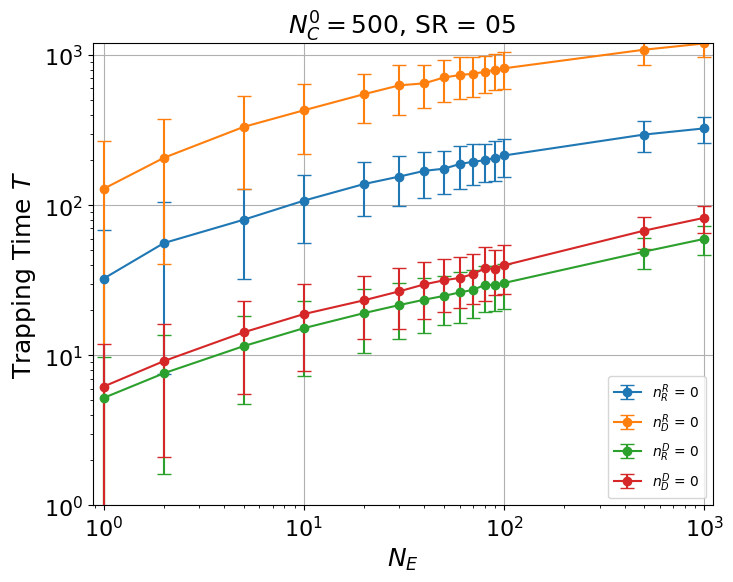

In [57]:
dfs_list =[
[
df_NP01_NH500_TCC_005_TCT_005_O_00_SR05, 
df_NP02_NH500_TCC_005_TCT_005_O_00_SR05, 
df_NP05_NH500_TCC_005_TCT_005_O_00_SR05, 
df_NP10_NH500_TCC_005_TCT_005_O_00_SR05,
df_NP20_NH500_TCC_005_TCT_005_O_00_SR05, 
df_NP30_NH500_TCC_005_TCT_005_O_00_SR05, 
df_NP40_NH500_TCC_005_TCT_005_O_00_SR05, 
df_NP50_NH500_TCC_005_TCT_005_O_00_SR05,
df_NP60_NH500_TCC_005_TCT_005_O_00_SR05, 
df_NP70_NH500_TCC_005_TCT_005_O_00_SR05, 
df_NP80_NH500_TCC_005_TCT_005_O_00_SR05, 
df_NP90_NH500_TCC_005_TCT_005_O_00_SR05,
df_NP100_NH500_TCC_005_TCT_005_O_00_SR05, 
df_NP500_NH500_TCC_005_TCT_005_O_00_SR05,
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR05
], 
[
df_NP01_NH500_TCC_095_TCT_005_O_00_SR05, 
df_NP02_NH500_TCC_095_TCT_005_O_00_SR05, 
df_NP05_NH500_TCC_095_TCT_005_O_00_SR05, 
df_NP10_NH500_TCC_095_TCT_005_O_00_SR05,
df_NP20_NH500_TCC_095_TCT_005_O_00_SR05, 
df_NP30_NH500_TCC_095_TCT_005_O_00_SR05, 
df_NP40_NH500_TCC_095_TCT_005_O_00_SR05, 
df_NP50_NH500_TCC_095_TCT_005_O_00_SR05,
df_NP60_NH500_TCC_095_TCT_005_O_00_SR05, 
df_NP70_NH500_TCC_095_TCT_005_O_00_SR05, 
df_NP80_NH500_TCC_095_TCT_005_O_00_SR05, 
df_NP90_NH500_TCC_095_TCT_005_O_00_SR05,
df_NP100_NH500_TCC_095_TCT_005_O_00_SR05, 
df_NP500_NH500_TCC_095_TCT_005_O_00_SR05,
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR05
], 
[
df_NP01_NH500_TCC_005_TCT_095_O_00_SR05, 
df_NP02_NH500_TCC_005_TCT_095_O_00_SR05, 
df_NP05_NH500_TCC_005_TCT_095_O_00_SR05, 
df_NP10_NH500_TCC_005_TCT_095_O_00_SR05,
df_NP20_NH500_TCC_005_TCT_095_O_00_SR05, 
df_NP30_NH500_TCC_005_TCT_095_O_00_SR05, 
df_NP40_NH500_TCC_005_TCT_095_O_00_SR05, 
df_NP50_NH500_TCC_005_TCT_095_O_00_SR05,
df_NP60_NH500_TCC_005_TCT_095_O_00_SR05, 
df_NP70_NH500_TCC_005_TCT_095_O_00_SR05, 
df_NP80_NH500_TCC_005_TCT_095_O_00_SR05, 
df_NP90_NH500_TCC_005_TCT_095_O_00_SR05,
df_NP100_NH500_TCC_005_TCT_095_O_00_SR05, 
df_NP500_NH500_TCC_005_TCT_095_O_00_SR05,
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR05
], 

[
df_NP01_NH500_TCC_095_TCT_095_O_00_SR05, 
df_NP02_NH500_TCC_095_TCT_095_O_00_SR05, 
df_NP05_NH500_TCC_095_TCT_095_O_00_SR05, 
df_NP10_NH500_TCC_095_TCT_095_O_00_SR05,
df_NP20_NH500_TCC_095_TCT_095_O_00_SR05, 
df_NP30_NH500_TCC_095_TCT_095_O_00_SR05, 
df_NP40_NH500_TCC_095_TCT_095_O_00_SR05, 
df_NP50_NH500_TCC_095_TCT_095_O_00_SR05,
df_NP60_NH500_TCC_095_TCT_095_O_00_SR05, 
df_NP70_NH500_TCC_095_TCT_095_O_00_SR05, 
df_NP80_NH500_TCC_095_TCT_095_O_00_SR05, 
df_NP90_NH500_TCC_095_TCT_095_O_00_SR05,
df_NP100_NH500_TCC_095_TCT_095_O_00_SR05, 
df_NP500_NH500_TCC_095_TCT_095_O_00_SR05,
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR05
]
]

nc_values = [
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.0
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.02
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],   # Valores de NC para O = 0.05
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000]
]

labels =[
        #Para o caso 0.05
        "$n_{R}^{R}$ = 0", "$n_{D}^{R}$ = 0",
        "$n_{R}^{D}$ = 0","$n_{D}^{D}$ = 0"
        ]

plotar_media_steps_com_erro(
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, SR = 05", 
    xlabel="$N_{E}$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=8.8e-1, x_max=1.1e3, 
    y_min=1e0, y_max=1200, 
    #save_path="trap_x_n_prey_CTN_050_CCN_050_SR_5_O_v.png")
    save_path="trap_x_n_prey_TCC_both_TCT_both_SR_5_O_0.pdf")

### SR = 5, n = 51

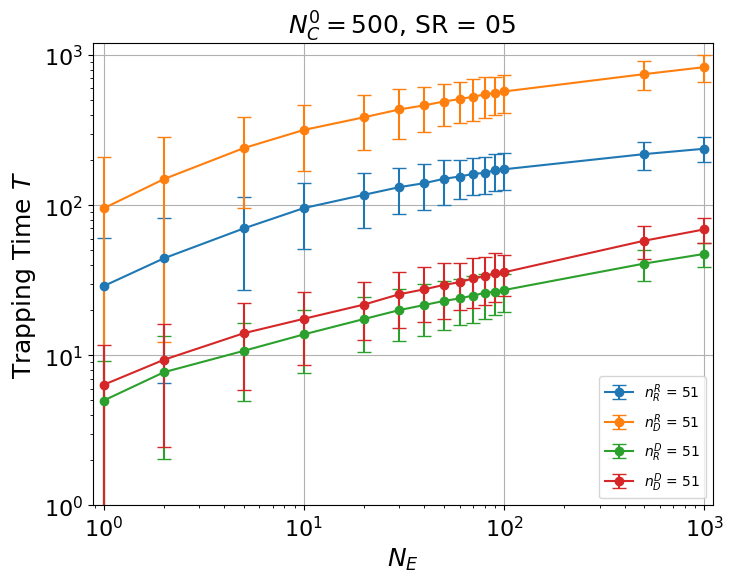

In [58]:
dfs_list =[
[
df_NP01_NH500_TCC_005_TCT_005_O_51_SR05, 
df_NP02_NH500_TCC_005_TCT_005_O_51_SR05, 
df_NP05_NH500_TCC_005_TCT_005_O_51_SR05, 
df_NP10_NH500_TCC_005_TCT_005_O_51_SR05,
df_NP20_NH500_TCC_005_TCT_005_O_51_SR05, 
df_NP30_NH500_TCC_005_TCT_005_O_51_SR05, 
df_NP40_NH500_TCC_005_TCT_005_O_51_SR05, 
df_NP50_NH500_TCC_005_TCT_005_O_51_SR05,
df_NP60_NH500_TCC_005_TCT_005_O_51_SR05, 
df_NP70_NH500_TCC_005_TCT_005_O_51_SR05, 
df_NP80_NH500_TCC_005_TCT_005_O_51_SR05, 
df_NP90_NH500_TCC_005_TCT_005_O_51_SR05,
df_NP100_NH500_TCC_005_TCT_005_O_51_SR05, 
df_NP500_NH500_TCC_005_TCT_005_O_51_SR05,
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR05
], 
[
df_NP01_NH500_TCC_095_TCT_005_O_51_SR05, 
df_NP02_NH500_TCC_095_TCT_005_O_51_SR05, 
df_NP05_NH500_TCC_095_TCT_005_O_51_SR05, 
df_NP10_NH500_TCC_095_TCT_005_O_51_SR05,
df_NP20_NH500_TCC_095_TCT_005_O_51_SR05, 
df_NP30_NH500_TCC_095_TCT_005_O_51_SR05, 
df_NP40_NH500_TCC_095_TCT_005_O_51_SR05, 
df_NP50_NH500_TCC_095_TCT_005_O_51_SR05,
df_NP60_NH500_TCC_095_TCT_005_O_51_SR05, 
df_NP70_NH500_TCC_095_TCT_005_O_51_SR05, 
df_NP80_NH500_TCC_095_TCT_005_O_51_SR05, 
df_NP90_NH500_TCC_095_TCT_005_O_51_SR05,
df_NP100_NH500_TCC_095_TCT_005_O_51_SR05, 
df_NP500_NH500_TCC_095_TCT_005_O_51_SR05,
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR05
], 
[
df_NP01_NH500_TCC_005_TCT_095_O_51_SR05, 
df_NP02_NH500_TCC_005_TCT_095_O_51_SR05, 
df_NP05_NH500_TCC_005_TCT_095_O_51_SR05, 
df_NP10_NH500_TCC_005_TCT_095_O_51_SR05,
df_NP20_NH500_TCC_005_TCT_095_O_51_SR05, 
df_NP30_NH500_TCC_005_TCT_095_O_51_SR05, 
df_NP40_NH500_TCC_005_TCT_095_O_51_SR05, 
df_NP50_NH500_TCC_005_TCT_095_O_51_SR05,
df_NP60_NH500_TCC_005_TCT_095_O_51_SR05, 
df_NP70_NH500_TCC_005_TCT_095_O_51_SR05, 
df_NP80_NH500_TCC_005_TCT_095_O_51_SR05, 
df_NP90_NH500_TCC_005_TCT_095_O_51_SR05,
df_NP100_NH500_TCC_005_TCT_095_O_51_SR05, 
df_NP500_NH500_TCC_005_TCT_095_O_51_SR05,
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR05
], 

[
df_NP01_NH500_TCC_095_TCT_095_O_51_SR05, 
df_NP02_NH500_TCC_095_TCT_095_O_51_SR05, 
df_NP05_NH500_TCC_095_TCT_095_O_51_SR05, 
df_NP10_NH500_TCC_095_TCT_095_O_51_SR05,
df_NP20_NH500_TCC_095_TCT_095_O_51_SR05, 
df_NP30_NH500_TCC_095_TCT_095_O_51_SR05, 
df_NP40_NH500_TCC_095_TCT_095_O_51_SR05, 
df_NP50_NH500_TCC_095_TCT_095_O_51_SR05,
df_NP60_NH500_TCC_095_TCT_095_O_51_SR05, 
df_NP70_NH500_TCC_095_TCT_095_O_51_SR05, 
df_NP80_NH500_TCC_095_TCT_095_O_51_SR05, 
df_NP90_NH500_TCC_095_TCT_095_O_51_SR05,
df_NP100_NH500_TCC_095_TCT_095_O_51_SR05, 
df_NP500_NH500_TCC_095_TCT_095_O_51_SR05,
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR05
]
]

nc_values = [
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.0
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.02
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],   # Valores de NC para O = 0.05
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000]
]

labels =[
        #Para o caso 0.05
        "$n_{R}^{R}$ = 51", "$n_{D}^{R}$ = 51",
        "$n_{R}^{D}$ = 51","$n_{D}^{D}$ = 51"
        ]

plotar_media_steps_com_erro(
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, SR = 05", 
    xlabel="$N_{E}$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=8.8e-1, x_max=1.1e3, 
    y_min=1e0, y_max=1200, 
    #save_path="trap_x_n_prey_CTN_050_CCN_050_SR_5_O_v.png")
    save_path="trap_x_n_prey_TCC_both_TCT_both_SR_5_O_51.pdf")

### SR = 10, n = 0

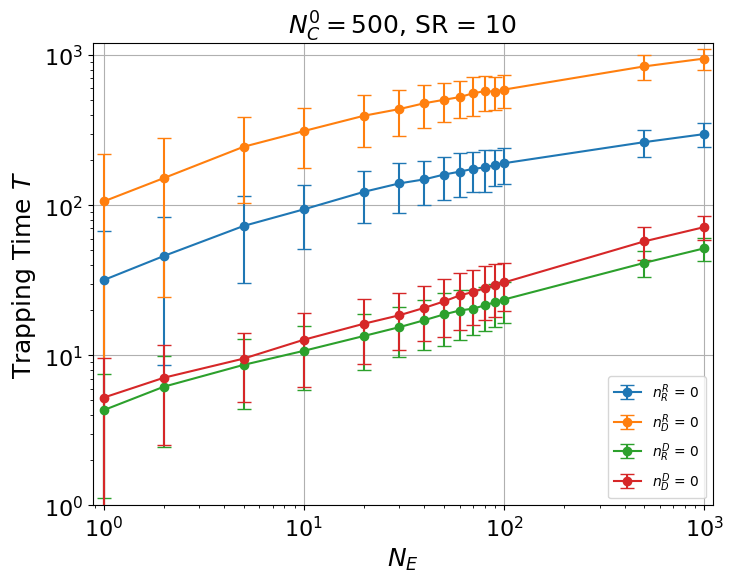

In [59]:
dfs_list =[
[
df_NP01_NH500_TCC_005_TCT_005_O_00_SR10, 
df_NP02_NH500_TCC_005_TCT_005_O_00_SR10, 
df_NP05_NH500_TCC_005_TCT_005_O_00_SR10, 
df_NP10_NH500_TCC_005_TCT_005_O_00_SR10,
df_NP20_NH500_TCC_005_TCT_005_O_00_SR10, 
df_NP30_NH500_TCC_005_TCT_005_O_00_SR10, 
df_NP40_NH500_TCC_005_TCT_005_O_00_SR10, 
df_NP50_NH500_TCC_005_TCT_005_O_00_SR10,
df_NP60_NH500_TCC_005_TCT_005_O_00_SR10, 
df_NP70_NH500_TCC_005_TCT_005_O_00_SR10, 
df_NP80_NH500_TCC_005_TCT_005_O_00_SR10, 
df_NP90_NH500_TCC_005_TCT_005_O_00_SR10,
df_NP100_NH500_TCC_005_TCT_005_O_00_SR10, 
df_NP500_NH500_TCC_005_TCT_005_O_00_SR10,
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR10
], 
[
df_NP01_NH500_TCC_095_TCT_005_O_00_SR10, 
df_NP02_NH500_TCC_095_TCT_005_O_00_SR10, 
df_NP05_NH500_TCC_095_TCT_005_O_00_SR10, 
df_NP10_NH500_TCC_095_TCT_005_O_00_SR10,
df_NP20_NH500_TCC_095_TCT_005_O_00_SR10, 
df_NP30_NH500_TCC_095_TCT_005_O_00_SR10, 
df_NP40_NH500_TCC_095_TCT_005_O_00_SR10, 
df_NP50_NH500_TCC_095_TCT_005_O_00_SR10,
df_NP60_NH500_TCC_095_TCT_005_O_00_SR10, 
df_NP70_NH500_TCC_095_TCT_005_O_00_SR10, 
df_NP80_NH500_TCC_095_TCT_005_O_00_SR10, 
df_NP90_NH500_TCC_095_TCT_005_O_00_SR10,
df_NP100_NH500_TCC_095_TCT_005_O_00_SR10, 
df_NP500_NH500_TCC_095_TCT_005_O_00_SR10,
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR10
], 
[
df_NP01_NH500_TCC_005_TCT_095_O_00_SR10, 
df_NP02_NH500_TCC_005_TCT_095_O_00_SR10, 
df_NP05_NH500_TCC_005_TCT_095_O_00_SR10, 
df_NP10_NH500_TCC_005_TCT_095_O_00_SR10,
df_NP20_NH500_TCC_005_TCT_095_O_00_SR10, 
df_NP30_NH500_TCC_005_TCT_095_O_00_SR10, 
df_NP40_NH500_TCC_005_TCT_095_O_00_SR10, 
df_NP50_NH500_TCC_005_TCT_095_O_00_SR10,
df_NP60_NH500_TCC_005_TCT_095_O_00_SR10, 
df_NP70_NH500_TCC_005_TCT_095_O_00_SR10, 
df_NP80_NH500_TCC_005_TCT_095_O_00_SR10, 
df_NP90_NH500_TCC_005_TCT_095_O_00_SR10,
df_NP100_NH500_TCC_005_TCT_095_O_00_SR10, 
df_NP500_NH500_TCC_005_TCT_095_O_00_SR10,
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR10
], 

[
df_NP01_NH500_TCC_095_TCT_095_O_00_SR10, 
df_NP02_NH500_TCC_095_TCT_095_O_00_SR10, 
df_NP05_NH500_TCC_095_TCT_095_O_00_SR10, 
df_NP10_NH500_TCC_095_TCT_095_O_00_SR10,
df_NP20_NH500_TCC_095_TCT_095_O_00_SR10, 
df_NP30_NH500_TCC_095_TCT_095_O_00_SR10, 
df_NP40_NH500_TCC_095_TCT_095_O_00_SR10, 
df_NP50_NH500_TCC_095_TCT_095_O_00_SR10,
df_NP60_NH500_TCC_095_TCT_095_O_00_SR10, 
df_NP70_NH500_TCC_095_TCT_095_O_00_SR10, 
df_NP80_NH500_TCC_095_TCT_095_O_00_SR10, 
df_NP90_NH500_TCC_095_TCT_095_O_00_SR10,
df_NP100_NH500_TCC_095_TCT_095_O_00_SR10, 
df_NP500_NH500_TCC_095_TCT_095_O_00_SR10,
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR10
]
]

nc_values = [
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.0
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.02
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],   # Valores de NC para O = 0.05
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000]
]

labels =[
        #Para o caso 0.05
        "$n_{R}^{R}$ = 0","$n_{D}^{R}$ = 0",
        "$n_{R}^{D}$ = 0","$n_{D}^{D}$ = 0"
        ]

plotar_media_steps_com_erro(
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, SR = 10", 
    xlabel="$N_{E}$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=8.8e-1, x_max=1.1e3, 
    y_min=1e0, y_max=1200, 
    #save_path="trap_x_n_prey_CTN_050_CCN_050_SR_5_O_v.png")
    save_path="trap_x_n_prey_TCC_both_TCT_both_SR_10_O_0.pdf")

### SR = 10, n = 51

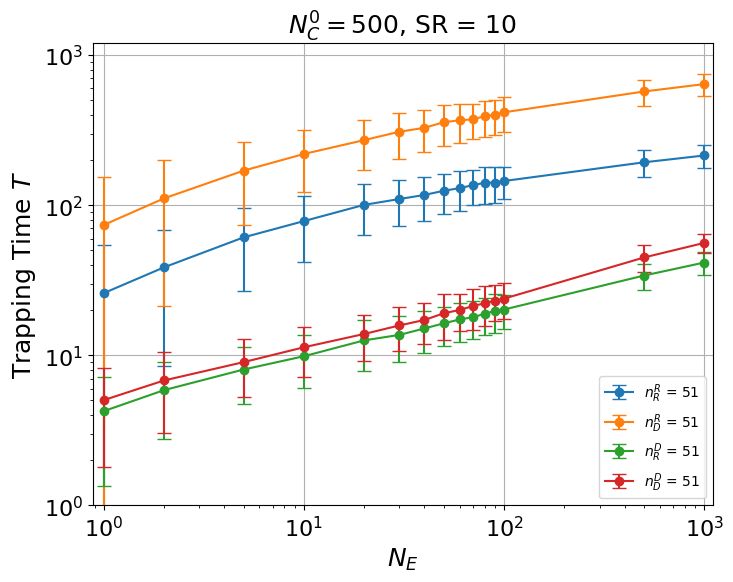

In [60]:
dfs_list =[
[
df_NP01_NH500_TCC_005_TCT_005_O_51_SR10, 
df_NP02_NH500_TCC_005_TCT_005_O_51_SR10, 
df_NP05_NH500_TCC_005_TCT_005_O_51_SR10, 
df_NP10_NH500_TCC_005_TCT_005_O_51_SR10,
df_NP20_NH500_TCC_005_TCT_005_O_51_SR10, 
df_NP30_NH500_TCC_005_TCT_005_O_51_SR10, 
df_NP40_NH500_TCC_005_TCT_005_O_51_SR10, 
df_NP50_NH500_TCC_005_TCT_005_O_51_SR10,
df_NP60_NH500_TCC_005_TCT_005_O_51_SR10, 
df_NP70_NH500_TCC_005_TCT_005_O_51_SR10, 
df_NP80_NH500_TCC_005_TCT_005_O_51_SR10, 
df_NP90_NH500_TCC_005_TCT_005_O_51_SR10,
df_NP100_NH500_TCC_005_TCT_005_O_51_SR10, 
df_NP500_NH500_TCC_005_TCT_005_O_51_SR10,
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR10
], 
[
df_NP01_NH500_TCC_095_TCT_005_O_51_SR10, 
df_NP02_NH500_TCC_095_TCT_005_O_51_SR10, 
df_NP05_NH500_TCC_095_TCT_005_O_51_SR10, 
df_NP10_NH500_TCC_095_TCT_005_O_51_SR10,
df_NP20_NH500_TCC_095_TCT_005_O_51_SR10, 
df_NP30_NH500_TCC_095_TCT_005_O_51_SR10, 
df_NP40_NH500_TCC_095_TCT_005_O_51_SR10, 
df_NP50_NH500_TCC_095_TCT_005_O_51_SR10,
df_NP60_NH500_TCC_095_TCT_005_O_51_SR10, 
df_NP70_NH500_TCC_095_TCT_005_O_51_SR10, 
df_NP80_NH500_TCC_095_TCT_005_O_51_SR10, 
df_NP90_NH500_TCC_095_TCT_005_O_51_SR10,
df_NP100_NH500_TCC_095_TCT_005_O_51_SR10, 
df_NP500_NH500_TCC_095_TCT_005_O_51_SR10,
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR10
], 
[
df_NP01_NH500_TCC_005_TCT_095_O_51_SR10, 
df_NP02_NH500_TCC_005_TCT_095_O_51_SR10, 
df_NP05_NH500_TCC_005_TCT_095_O_51_SR10, 
df_NP10_NH500_TCC_005_TCT_095_O_51_SR10,
df_NP20_NH500_TCC_005_TCT_095_O_51_SR10, 
df_NP30_NH500_TCC_005_TCT_095_O_51_SR10, 
df_NP40_NH500_TCC_005_TCT_095_O_51_SR10, 
df_NP50_NH500_TCC_005_TCT_095_O_51_SR10,
df_NP60_NH500_TCC_005_TCT_095_O_51_SR10, 
df_NP70_NH500_TCC_005_TCT_095_O_51_SR10, 
df_NP80_NH500_TCC_005_TCT_095_O_51_SR10, 
df_NP90_NH500_TCC_005_TCT_095_O_51_SR10,
df_NP100_NH500_TCC_005_TCT_095_O_51_SR10, 
df_NP500_NH500_TCC_005_TCT_095_O_51_SR10,
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR10
], 

[
df_NP01_NH500_TCC_095_TCT_095_O_51_SR10, 
df_NP02_NH500_TCC_095_TCT_095_O_51_SR10, 
df_NP05_NH500_TCC_095_TCT_095_O_51_SR10, 
df_NP10_NH500_TCC_095_TCT_095_O_51_SR10,
df_NP20_NH500_TCC_095_TCT_095_O_51_SR10, 
df_NP30_NH500_TCC_095_TCT_095_O_51_SR10, 
df_NP40_NH500_TCC_095_TCT_095_O_51_SR10, 
df_NP50_NH500_TCC_095_TCT_095_O_51_SR10,
df_NP60_NH500_TCC_095_TCT_095_O_51_SR10, 
df_NP70_NH500_TCC_095_TCT_095_O_51_SR10, 
df_NP80_NH500_TCC_095_TCT_095_O_51_SR10, 
df_NP90_NH500_TCC_095_TCT_095_O_51_SR10,
df_NP100_NH500_TCC_095_TCT_095_O_51_SR10, 
df_NP500_NH500_TCC_095_TCT_095_O_51_SR10,
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR10
]
]

nc_values = [
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.0
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.02
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],   # Valores de NC para O = 0.05
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000]
]

labels =[
        #Para o caso 0.05
        "$n_{R}^{R}$ = 51","$n_{D}^{R}$ = 51",
        "$n_{R}^{D}$ = 51","$n_{D}^{D}$ = 51"
        ]

plotar_media_steps_com_erro(
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, SR = 10", 
    xlabel="$N_{E}$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=8.8e-1, x_max=1.1e3, 
    y_min=1e0, y_max=1200, 
    #save_path="trap_x_n_prey_CTN_050_CCN_050_SR_5_O_v.png")
    save_path="trap_x_n_prey_TCC_both_TCT_both_SR_10_O_51.pdf")

### SR = 20, n = 0

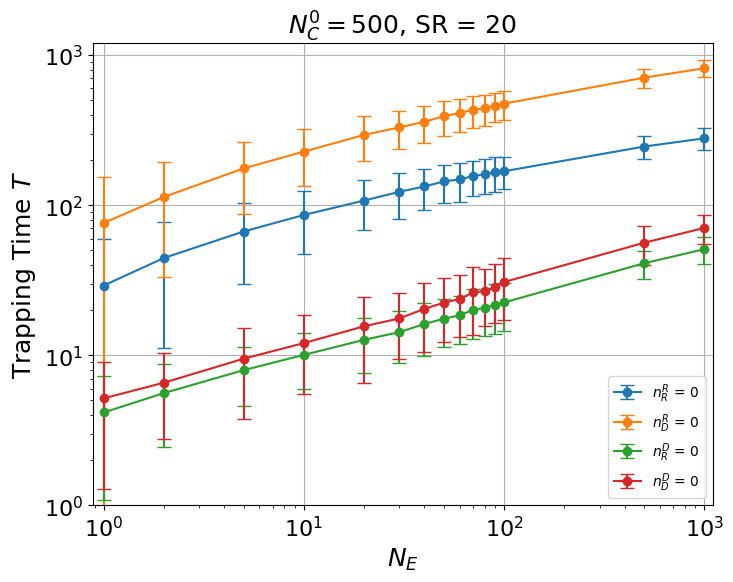

In [61]:
dfs_list =[
[
df_NP01_NH500_TCC_005_TCT_005_O_00_SR20, 
df_NP02_NH500_TCC_005_TCT_005_O_00_SR20, 
df_NP05_NH500_TCC_005_TCT_005_O_00_SR20, 
df_NP10_NH500_TCC_005_TCT_005_O_00_SR20,
df_NP20_NH500_TCC_005_TCT_005_O_00_SR20, 
df_NP30_NH500_TCC_005_TCT_005_O_00_SR20, 
df_NP40_NH500_TCC_005_TCT_005_O_00_SR20, 
df_NP50_NH500_TCC_005_TCT_005_O_00_SR20,
df_NP60_NH500_TCC_005_TCT_005_O_00_SR20, 
df_NP70_NH500_TCC_005_TCT_005_O_00_SR20, 
df_NP80_NH500_TCC_005_TCT_005_O_00_SR20, 
df_NP90_NH500_TCC_005_TCT_005_O_00_SR20,
df_NP100_NH500_TCC_005_TCT_005_O_00_SR20, 
df_NP500_NH500_TCC_005_TCT_005_O_00_SR20,
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR20
], 
[
df_NP01_NH500_TCC_095_TCT_005_O_00_SR20, 
df_NP02_NH500_TCC_095_TCT_005_O_00_SR20, 
df_NP05_NH500_TCC_095_TCT_005_O_00_SR20, 
df_NP10_NH500_TCC_095_TCT_005_O_00_SR20,
df_NP20_NH500_TCC_095_TCT_005_O_00_SR20, 
df_NP30_NH500_TCC_095_TCT_005_O_00_SR20, 
df_NP40_NH500_TCC_095_TCT_005_O_00_SR20, 
df_NP50_NH500_TCC_095_TCT_005_O_00_SR20,
df_NP60_NH500_TCC_095_TCT_005_O_00_SR20, 
df_NP70_NH500_TCC_095_TCT_005_O_00_SR20, 
df_NP80_NH500_TCC_095_TCT_005_O_00_SR20, 
df_NP90_NH500_TCC_095_TCT_005_O_00_SR20,
df_NP100_NH500_TCC_095_TCT_005_O_00_SR20, 
df_NP500_NH500_TCC_095_TCT_005_O_00_SR20,
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR20
], 
[
df_NP01_NH500_TCC_005_TCT_095_O_00_SR20, 
df_NP02_NH500_TCC_005_TCT_095_O_00_SR20, 
df_NP05_NH500_TCC_005_TCT_095_O_00_SR20, 
df_NP10_NH500_TCC_005_TCT_095_O_00_SR20,
df_NP20_NH500_TCC_005_TCT_095_O_00_SR20, 
df_NP30_NH500_TCC_005_TCT_095_O_00_SR20, 
df_NP40_NH500_TCC_005_TCT_095_O_00_SR20, 
df_NP50_NH500_TCC_005_TCT_095_O_00_SR20,
df_NP60_NH500_TCC_005_TCT_095_O_00_SR20, 
df_NP70_NH500_TCC_005_TCT_095_O_00_SR20, 
df_NP80_NH500_TCC_005_TCT_095_O_00_SR20, 
df_NP90_NH500_TCC_005_TCT_095_O_00_SR20,
df_NP100_NH500_TCC_005_TCT_095_O_00_SR20, 
df_NP500_NH500_TCC_005_TCT_095_O_00_SR20,
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR20
], 

[
df_NP01_NH500_TCC_095_TCT_095_O_00_SR20, 
df_NP02_NH500_TCC_095_TCT_095_O_00_SR20, 
df_NP05_NH500_TCC_095_TCT_095_O_00_SR20, 
df_NP10_NH500_TCC_095_TCT_095_O_00_SR20,
df_NP20_NH500_TCC_095_TCT_095_O_00_SR20, 
df_NP30_NH500_TCC_095_TCT_095_O_00_SR20, 
df_NP40_NH500_TCC_095_TCT_095_O_00_SR20, 
df_NP50_NH500_TCC_095_TCT_095_O_00_SR20,
df_NP60_NH500_TCC_095_TCT_095_O_00_SR20, 
df_NP70_NH500_TCC_095_TCT_095_O_00_SR20, 
df_NP80_NH500_TCC_095_TCT_095_O_00_SR20, 
df_NP90_NH500_TCC_095_TCT_095_O_00_SR20,
df_NP100_NH500_TCC_095_TCT_095_O_00_SR20, 
df_NP500_NH500_TCC_095_TCT_095_O_00_SR20,
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR20
]
]

nc_values = [
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.0
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.02
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],   # Valores de NC para O = 0.05
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000]
]

labels =[
        #Para o caso 0.05
        "$n_{R}^{R}$ = 0","$n_{D}^{R}$ = 0",
        "$n_{R}^{D}$ = 0","$n_{D}^{D}$ = 0"
        ]

plotar_media_steps_com_erro(
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, SR = 20", 
    xlabel="$N_{E}$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=8.8e-1, x_max=1.1e3, 
    y_min=1e0, y_max=1200, 
    #save_path="trap_x_n_prey_CTN_050_CCN_050_SR_5_O_v.png")
    save_path="trap_x_n_prey_TCC_both_TCT_both_SR_20_O_0.pdf")

### SR = 20, n = 51.

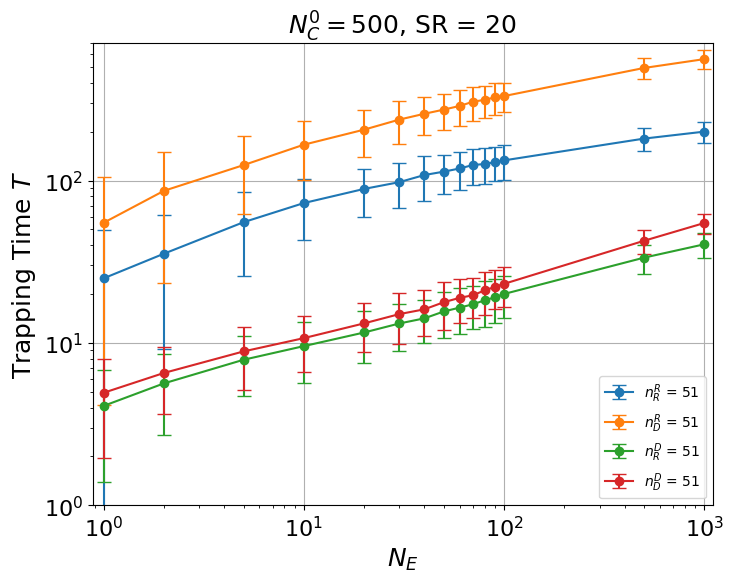

In [62]:
dfs_list =[
[
df_NP01_NH500_TCC_005_TCT_005_O_51_SR20, 
df_NP02_NH500_TCC_005_TCT_005_O_51_SR20, 
df_NP05_NH500_TCC_005_TCT_005_O_51_SR20, 
df_NP10_NH500_TCC_005_TCT_005_O_51_SR20,
df_NP20_NH500_TCC_005_TCT_005_O_51_SR20, 
df_NP30_NH500_TCC_005_TCT_005_O_51_SR20, 
df_NP40_NH500_TCC_005_TCT_005_O_51_SR20, 
df_NP50_NH500_TCC_005_TCT_005_O_51_SR20,
df_NP60_NH500_TCC_005_TCT_005_O_51_SR20, 
df_NP70_NH500_TCC_005_TCT_005_O_51_SR20, 
df_NP80_NH500_TCC_005_TCT_005_O_51_SR20, 
df_NP90_NH500_TCC_005_TCT_005_O_51_SR20,
df_NP100_NH500_TCC_005_TCT_005_O_51_SR20, 
df_NP500_NH500_TCC_005_TCT_005_O_51_SR20,
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR20
], 
[
df_NP01_NH500_TCC_095_TCT_005_O_51_SR20, 
df_NP02_NH500_TCC_095_TCT_005_O_51_SR20, 
df_NP05_NH500_TCC_095_TCT_005_O_51_SR20, 
df_NP10_NH500_TCC_095_TCT_005_O_51_SR20,
df_NP20_NH500_TCC_095_TCT_005_O_51_SR20, 
df_NP30_NH500_TCC_095_TCT_005_O_51_SR20, 
df_NP40_NH500_TCC_095_TCT_005_O_51_SR20, 
df_NP50_NH500_TCC_095_TCT_005_O_51_SR20,
df_NP60_NH500_TCC_095_TCT_005_O_51_SR20, 
df_NP70_NH500_TCC_095_TCT_005_O_51_SR20, 
df_NP80_NH500_TCC_095_TCT_005_O_51_SR20, 
df_NP90_NH500_TCC_095_TCT_005_O_51_SR20,
df_NP100_NH500_TCC_095_TCT_005_O_51_SR20, 
df_NP500_NH500_TCC_095_TCT_005_O_51_SR20,
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR20
], 
[
df_NP01_NH500_TCC_005_TCT_095_O_51_SR20, 
df_NP02_NH500_TCC_005_TCT_095_O_51_SR20, 
df_NP05_NH500_TCC_005_TCT_095_O_51_SR20, 
df_NP10_NH500_TCC_005_TCT_095_O_51_SR20,
df_NP20_NH500_TCC_005_TCT_095_O_51_SR20, 
df_NP30_NH500_TCC_005_TCT_095_O_51_SR20, 
df_NP40_NH500_TCC_005_TCT_095_O_51_SR20, 
df_NP50_NH500_TCC_005_TCT_095_O_51_SR20,
df_NP60_NH500_TCC_005_TCT_095_O_51_SR20, 
df_NP70_NH500_TCC_005_TCT_095_O_51_SR20, 
df_NP80_NH500_TCC_005_TCT_095_O_51_SR20, 
df_NP90_NH500_TCC_005_TCT_095_O_51_SR20,
df_NP100_NH500_TCC_005_TCT_095_O_51_SR20, 
df_NP500_NH500_TCC_005_TCT_095_O_51_SR20,
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR20
], 

[
df_NP01_NH500_TCC_095_TCT_095_O_51_SR20, 
df_NP02_NH500_TCC_095_TCT_095_O_51_SR20, 
df_NP05_NH500_TCC_095_TCT_095_O_51_SR20, 
df_NP10_NH500_TCC_095_TCT_095_O_51_SR20,
df_NP20_NH500_TCC_095_TCT_095_O_51_SR20, 
df_NP30_NH500_TCC_095_TCT_095_O_51_SR20, 
df_NP40_NH500_TCC_095_TCT_095_O_51_SR20, 
df_NP50_NH500_TCC_095_TCT_095_O_51_SR20,
df_NP60_NH500_TCC_095_TCT_095_O_51_SR20, 
df_NP70_NH500_TCC_095_TCT_095_O_51_SR20, 
df_NP80_NH500_TCC_095_TCT_095_O_51_SR20, 
df_NP90_NH500_TCC_095_TCT_095_O_51_SR20,
df_NP100_NH500_TCC_095_TCT_095_O_51_SR20, 
df_NP500_NH500_TCC_095_TCT_095_O_51_SR20,
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR20
]
]

nc_values = [
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.0
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.02
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],   # Valores de NC para O = 0.05
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000]
]

labels =[
        #Para o caso 0.05
        "$n_{R}^{R}$ = 51","$n_{D}^{R}$ = 51",
        "$n_{R}^{D}$ = 51","$n_{D}^{D}$ = 51"
        ]

plotar_media_steps_com_erro(
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, SR = 20", 
    xlabel="$N_{E}$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=8.8e-1, x_max=1.1e3, 
    y_min=1e0, y_max=700, 
    #save_path="trap_x_n_prey_CTN_050_CCN_050_SR_5_O_v.png")
    save_path="trap_x_n_prey_TCC_both_TCT_both_SR_20_O_51.pdf")

### SR = 30, n = 0.

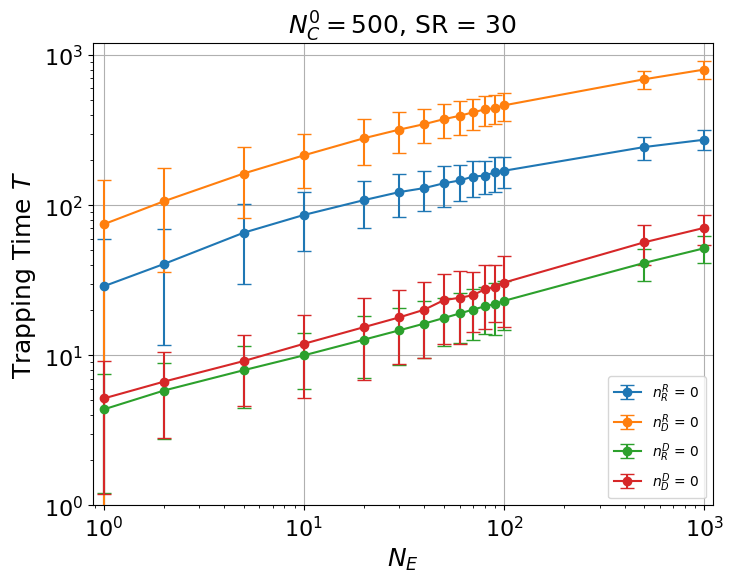

In [63]:
dfs_list =[
[
df_NP01_NH500_TCC_005_TCT_005_O_00_SR30, 
df_NP02_NH500_TCC_005_TCT_005_O_00_SR30, 
df_NP05_NH500_TCC_005_TCT_005_O_00_SR30, 
df_NP10_NH500_TCC_005_TCT_005_O_00_SR30,
df_NP20_NH500_TCC_005_TCT_005_O_00_SR30, 
df_NP30_NH500_TCC_005_TCT_005_O_00_SR30, 
df_NP40_NH500_TCC_005_TCT_005_O_00_SR30, 
df_NP50_NH500_TCC_005_TCT_005_O_00_SR30,
df_NP60_NH500_TCC_005_TCT_005_O_00_SR30, 
df_NP70_NH500_TCC_005_TCT_005_O_00_SR30, 
df_NP80_NH500_TCC_005_TCT_005_O_00_SR30, 
df_NP90_NH500_TCC_005_TCT_005_O_00_SR30,
df_NP100_NH500_TCC_005_TCT_005_O_00_SR30, 
df_NP500_NH500_TCC_005_TCT_005_O_00_SR30,
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR30
], 
[
df_NP01_NH500_TCC_095_TCT_005_O_00_SR30, 
df_NP02_NH500_TCC_095_TCT_005_O_00_SR30, 
df_NP05_NH500_TCC_095_TCT_005_O_00_SR30, 
df_NP10_NH500_TCC_095_TCT_005_O_00_SR30,
df_NP20_NH500_TCC_095_TCT_005_O_00_SR30, 
df_NP30_NH500_TCC_095_TCT_005_O_00_SR30, 
df_NP40_NH500_TCC_095_TCT_005_O_00_SR30, 
df_NP50_NH500_TCC_095_TCT_005_O_00_SR30,
df_NP60_NH500_TCC_095_TCT_005_O_00_SR30, 
df_NP70_NH500_TCC_095_TCT_005_O_00_SR30, 
df_NP80_NH500_TCC_095_TCT_005_O_00_SR30, 
df_NP90_NH500_TCC_095_TCT_005_O_00_SR30,
df_NP100_NH500_TCC_095_TCT_005_O_00_SR30, 
df_NP500_NH500_TCC_095_TCT_005_O_00_SR30,
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR30
], 
[
df_NP01_NH500_TCC_005_TCT_095_O_00_SR30, 
df_NP02_NH500_TCC_005_TCT_095_O_00_SR30, 
df_NP05_NH500_TCC_005_TCT_095_O_00_SR30, 
df_NP10_NH500_TCC_005_TCT_095_O_00_SR30,
df_NP20_NH500_TCC_005_TCT_095_O_00_SR30, 
df_NP30_NH500_TCC_005_TCT_095_O_00_SR30, 
df_NP40_NH500_TCC_005_TCT_095_O_00_SR30, 
df_NP50_NH500_TCC_005_TCT_095_O_00_SR30,
df_NP60_NH500_TCC_005_TCT_095_O_00_SR30, 
df_NP70_NH500_TCC_005_TCT_095_O_00_SR30, 
df_NP80_NH500_TCC_005_TCT_095_O_00_SR30, 
df_NP90_NH500_TCC_005_TCT_095_O_00_SR30,
df_NP100_NH500_TCC_005_TCT_095_O_00_SR30, 
df_NP500_NH500_TCC_005_TCT_095_O_00_SR30,
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR30
], 

[
df_NP01_NH500_TCC_095_TCT_095_O_00_SR30, 
df_NP02_NH500_TCC_095_TCT_095_O_00_SR30, 
df_NP05_NH500_TCC_095_TCT_095_O_00_SR30, 
df_NP10_NH500_TCC_095_TCT_095_O_00_SR30,
df_NP20_NH500_TCC_095_TCT_095_O_00_SR30, 
df_NP30_NH500_TCC_095_TCT_095_O_00_SR30, 
df_NP40_NH500_TCC_095_TCT_095_O_00_SR30, 
df_NP50_NH500_TCC_095_TCT_095_O_00_SR30,
df_NP60_NH500_TCC_095_TCT_095_O_00_SR30, 
df_NP70_NH500_TCC_095_TCT_095_O_00_SR30, 
df_NP80_NH500_TCC_095_TCT_095_O_00_SR30, 
df_NP90_NH500_TCC_095_TCT_095_O_00_SR30,
df_NP100_NH500_TCC_095_TCT_095_O_00_SR30, 
df_NP500_NH500_TCC_095_TCT_095_O_00_SR30,
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR30
]
]

nc_values = [
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.0
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.02
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],   # Valores de NC para O = 0.05
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000]
]

labels =[
        #Para o caso 0.05
        "$n_{R}^{R}$ = 0","$n_{D}^{R}$ = 0",
        "$n_{R}^{D}$ = 0","$n_{D}^{D}$ = 0"
        ]

plotar_media_steps_com_erro(
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, SR = 30", 
    xlabel="$N_{E}$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=8.8e-1, x_max=1.1e3, 
    y_min=1e0, y_max=1200, 
    #save_path="trap_x_n_prey_CTN_050_CCN_050_SR_5_O_v.png")
    save_path="trap_x_n_prey_TCC_both_TCT_both_SR_30_O_0.pdf")

### SR = 30, n = 51.

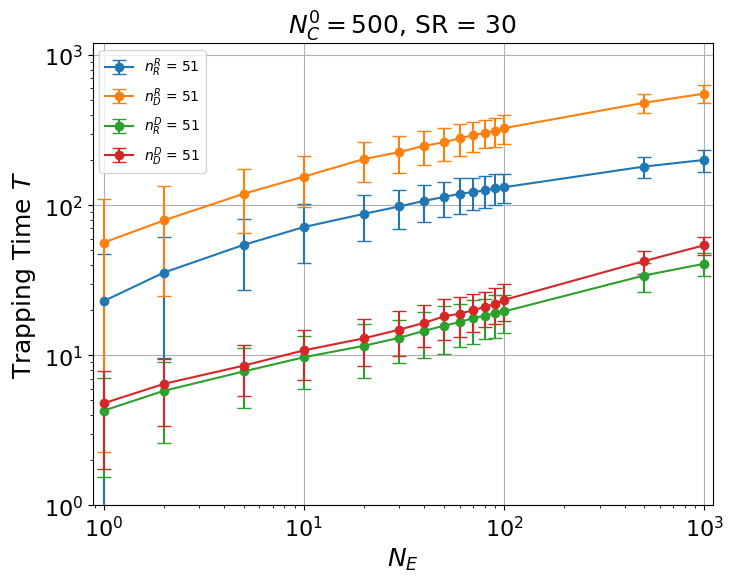

In [64]:
dfs_list =[
[
df_NP01_NH500_TCC_005_TCT_005_O_51_SR30, 
df_NP02_NH500_TCC_005_TCT_005_O_51_SR30, 
df_NP05_NH500_TCC_005_TCT_005_O_51_SR30, 
df_NP10_NH500_TCC_005_TCT_005_O_51_SR30,
df_NP20_NH500_TCC_005_TCT_005_O_51_SR30, 
df_NP30_NH500_TCC_005_TCT_005_O_51_SR30, 
df_NP40_NH500_TCC_005_TCT_005_O_51_SR30, 
df_NP50_NH500_TCC_005_TCT_005_O_51_SR30,
df_NP60_NH500_TCC_005_TCT_005_O_51_SR30, 
df_NP70_NH500_TCC_005_TCT_005_O_51_SR30, 
df_NP80_NH500_TCC_005_TCT_005_O_51_SR30, 
df_NP90_NH500_TCC_005_TCT_005_O_51_SR30,
df_NP100_NH500_TCC_005_TCT_005_O_51_SR30, 
df_NP500_NH500_TCC_005_TCT_005_O_51_SR30,
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR30
], 
[
df_NP01_NH500_TCC_095_TCT_005_O_51_SR30, 
df_NP02_NH500_TCC_095_TCT_005_O_51_SR30, 
df_NP05_NH500_TCC_095_TCT_005_O_51_SR30, 
df_NP10_NH500_TCC_095_TCT_005_O_51_SR30,
df_NP20_NH500_TCC_095_TCT_005_O_51_SR30, 
df_NP30_NH500_TCC_095_TCT_005_O_51_SR30, 
df_NP40_NH500_TCC_095_TCT_005_O_51_SR30, 
df_NP50_NH500_TCC_095_TCT_005_O_51_SR30,
df_NP60_NH500_TCC_095_TCT_005_O_51_SR30, 
df_NP70_NH500_TCC_095_TCT_005_O_51_SR30, 
df_NP80_NH500_TCC_095_TCT_005_O_51_SR30, 
df_NP90_NH500_TCC_095_TCT_005_O_51_SR30,
df_NP100_NH500_TCC_095_TCT_005_O_51_SR30, 
df_NP500_NH500_TCC_095_TCT_005_O_51_SR30,
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR30
], 
[
df_NP01_NH500_TCC_005_TCT_095_O_51_SR30, 
df_NP02_NH500_TCC_005_TCT_095_O_51_SR30, 
df_NP05_NH500_TCC_005_TCT_095_O_51_SR30, 
df_NP10_NH500_TCC_005_TCT_095_O_51_SR30,
df_NP20_NH500_TCC_005_TCT_095_O_51_SR30, 
df_NP30_NH500_TCC_005_TCT_095_O_51_SR30, 
df_NP40_NH500_TCC_005_TCT_095_O_51_SR30, 
df_NP50_NH500_TCC_005_TCT_095_O_51_SR30,
df_NP60_NH500_TCC_005_TCT_095_O_51_SR30, 
df_NP70_NH500_TCC_005_TCT_095_O_51_SR30, 
df_NP80_NH500_TCC_005_TCT_095_O_51_SR30, 
df_NP90_NH500_TCC_005_TCT_095_O_51_SR30,
df_NP100_NH500_TCC_005_TCT_095_O_51_SR30, 
df_NP500_NH500_TCC_005_TCT_095_O_51_SR30,
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR30
], 

[
df_NP01_NH500_TCC_095_TCT_095_O_51_SR30, 
df_NP02_NH500_TCC_095_TCT_095_O_51_SR30, 
df_NP05_NH500_TCC_095_TCT_095_O_51_SR30, 
df_NP10_NH500_TCC_095_TCT_095_O_51_SR30,
df_NP20_NH500_TCC_095_TCT_095_O_51_SR30, 
df_NP30_NH500_TCC_095_TCT_095_O_51_SR30, 
df_NP40_NH500_TCC_095_TCT_095_O_51_SR30, 
df_NP50_NH500_TCC_095_TCT_095_O_51_SR30,
df_NP60_NH500_TCC_095_TCT_095_O_51_SR30, 
df_NP70_NH500_TCC_095_TCT_095_O_51_SR30, 
df_NP80_NH500_TCC_095_TCT_095_O_51_SR30, 
df_NP90_NH500_TCC_095_TCT_095_O_51_SR30,
df_NP100_NH500_TCC_095_TCT_095_O_51_SR30, 
df_NP500_NH500_TCC_095_TCT_095_O_51_SR30,
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR30
]
]

nc_values = [
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.0
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.02
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],   # Valores de NC para O = 0.05
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000]
]

labels =[
        #Para o caso 0.05
        "$n_{R}^{R}$ = 51","$n_{D}^{R}$ = 51",
        "$n_{R}^{D}$ = 51","$n_{D}^{D}$ = 51"
        ]

plotar_media_steps_com_erro(
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, SR = 30", 
    xlabel="$N_{E}$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=8.8e-1, x_max=1.1e3, 
    y_min=1e0, y_max=1200, 
    #save_path="trap_x_n_prey_CTN_050_CCN_050_SR_5_O_v.png")
    save_path="trap_x_n_prey_TCC_both_TCT_both_SR_30_O_51.pdf")

### SR = 40, n = 0.

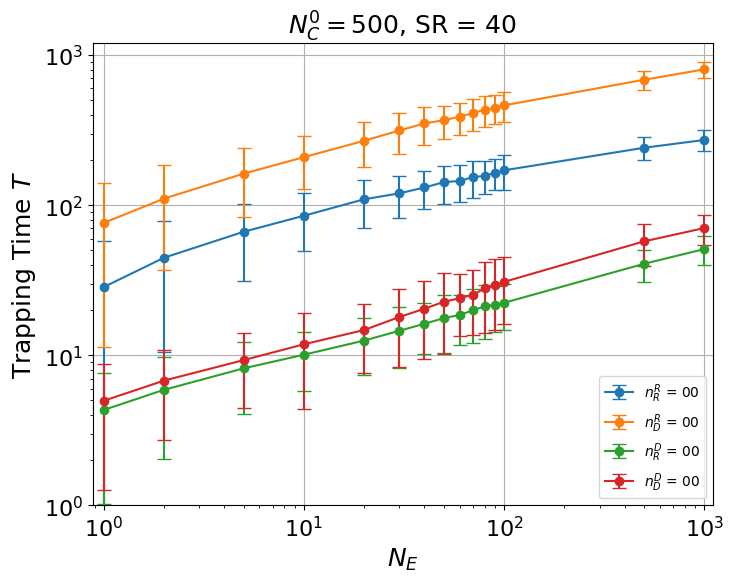

In [65]:
dfs_list =[
[
df_NP01_NH500_TCC_005_TCT_005_O_00_SR40, 
df_NP02_NH500_TCC_005_TCT_005_O_00_SR40, 
df_NP05_NH500_TCC_005_TCT_005_O_00_SR40, 
df_NP10_NH500_TCC_005_TCT_005_O_00_SR40,
df_NP20_NH500_TCC_005_TCT_005_O_00_SR40, 
df_NP30_NH500_TCC_005_TCT_005_O_00_SR40, 
df_NP40_NH500_TCC_005_TCT_005_O_00_SR40, 
df_NP50_NH500_TCC_005_TCT_005_O_00_SR40,
df_NP60_NH500_TCC_005_TCT_005_O_00_SR40, 
df_NP70_NH500_TCC_005_TCT_005_O_00_SR40, 
df_NP80_NH500_TCC_005_TCT_005_O_00_SR40, 
df_NP90_NH500_TCC_005_TCT_005_O_00_SR40,
df_NP100_NH500_TCC_005_TCT_005_O_00_SR40, 
df_NP500_NH500_TCC_005_TCT_005_O_00_SR40,
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR40
], 
[
df_NP01_NH500_TCC_095_TCT_005_O_00_SR40, 
df_NP02_NH500_TCC_095_TCT_005_O_00_SR40, 
df_NP05_NH500_TCC_095_TCT_005_O_00_SR40, 
df_NP10_NH500_TCC_095_TCT_005_O_00_SR40,
df_NP20_NH500_TCC_095_TCT_005_O_00_SR40, 
df_NP30_NH500_TCC_095_TCT_005_O_00_SR40, 
df_NP40_NH500_TCC_095_TCT_005_O_00_SR40, 
df_NP50_NH500_TCC_095_TCT_005_O_00_SR40,
df_NP60_NH500_TCC_095_TCT_005_O_00_SR40, 
df_NP70_NH500_TCC_095_TCT_005_O_00_SR40, 
df_NP80_NH500_TCC_095_TCT_005_O_00_SR40, 
df_NP90_NH500_TCC_095_TCT_005_O_00_SR40,
df_NP100_NH500_TCC_095_TCT_005_O_00_SR40, 
df_NP500_NH500_TCC_095_TCT_005_O_00_SR40,
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR40
], 
[
df_NP01_NH500_TCC_005_TCT_095_O_00_SR40, 
df_NP02_NH500_TCC_005_TCT_095_O_00_SR40, 
df_NP05_NH500_TCC_005_TCT_095_O_00_SR40, 
df_NP10_NH500_TCC_005_TCT_095_O_00_SR40,
df_NP20_NH500_TCC_005_TCT_095_O_00_SR40, 
df_NP30_NH500_TCC_005_TCT_095_O_00_SR40, 
df_NP40_NH500_TCC_005_TCT_095_O_00_SR40, 
df_NP50_NH500_TCC_005_TCT_095_O_00_SR40,
df_NP60_NH500_TCC_005_TCT_095_O_00_SR40, 
df_NP70_NH500_TCC_005_TCT_095_O_00_SR40, 
df_NP80_NH500_TCC_005_TCT_095_O_00_SR40, 
df_NP90_NH500_TCC_005_TCT_095_O_00_SR40,
df_NP100_NH500_TCC_005_TCT_095_O_00_SR40, 
df_NP500_NH500_TCC_005_TCT_095_O_00_SR40,
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR40
], 

[
df_NP01_NH500_TCC_095_TCT_095_O_00_SR40, 
df_NP02_NH500_TCC_095_TCT_095_O_00_SR40, 
df_NP05_NH500_TCC_095_TCT_095_O_00_SR40, 
df_NP10_NH500_TCC_095_TCT_095_O_00_SR40,
df_NP20_NH500_TCC_095_TCT_095_O_00_SR40, 
df_NP30_NH500_TCC_095_TCT_095_O_00_SR40, 
df_NP40_NH500_TCC_095_TCT_095_O_00_SR40, 
df_NP50_NH500_TCC_095_TCT_095_O_00_SR40,
df_NP60_NH500_TCC_095_TCT_095_O_00_SR40, 
df_NP70_NH500_TCC_095_TCT_095_O_00_SR40, 
df_NP80_NH500_TCC_095_TCT_095_O_00_SR40, 
df_NP90_NH500_TCC_095_TCT_095_O_00_SR40,
df_NP100_NH500_TCC_095_TCT_095_O_00_SR40, 
df_NP500_NH500_TCC_095_TCT_095_O_00_SR40,
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR40
]
]

nc_values = [
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.0
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.02
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],   # Valores de NC para O = 0.05
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000]
]

labels =[
        #Para o caso 0.05
        "$n_{R}^{R}$ = 00","$n_{D}^{R}$ = 00",
        "$n_{R}^{D}$ = 00","$n_{D}^{D}$ = 00"
        ]

plotar_media_steps_com_erro(
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, SR = 40", 
    xlabel="$N_{E}$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=8.8e-1, x_max=1.1e3, 
    y_min=1e0, y_max=1200, 
    #save_path="trap_x_n_prey_CTN_050_CCN_050_SR_5_O_v.png")
    save_path="trap_x_n_prey_TCC_both_TCT_both_SR_40_O_0.pdf")

### SR = 40, n = 51.

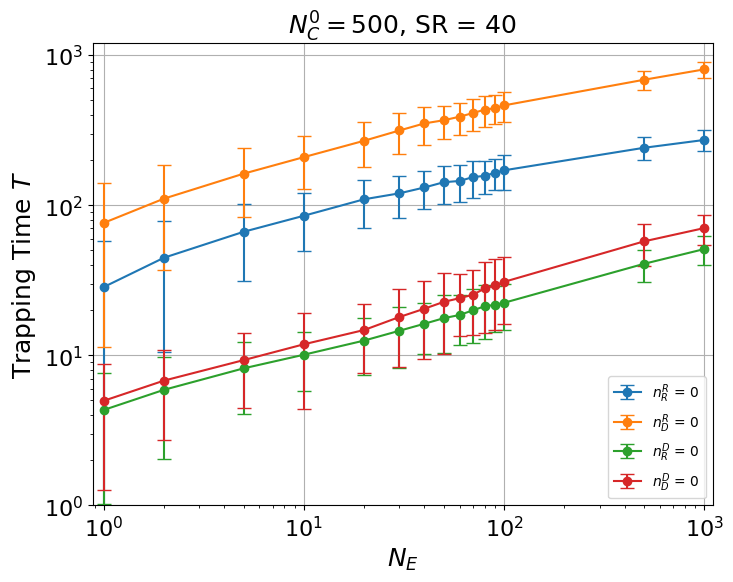

In [66]:
dfs_list =[
[
df_NP01_NH500_TCC_005_TCT_005_O_00_SR40, 
df_NP02_NH500_TCC_005_TCT_005_O_00_SR40, 
df_NP05_NH500_TCC_005_TCT_005_O_00_SR40, 
df_NP10_NH500_TCC_005_TCT_005_O_00_SR40,
df_NP20_NH500_TCC_005_TCT_005_O_00_SR40, 
df_NP30_NH500_TCC_005_TCT_005_O_00_SR40, 
df_NP40_NH500_TCC_005_TCT_005_O_00_SR40, 
df_NP50_NH500_TCC_005_TCT_005_O_00_SR40,
df_NP60_NH500_TCC_005_TCT_005_O_00_SR40, 
df_NP70_NH500_TCC_005_TCT_005_O_00_SR40, 
df_NP80_NH500_TCC_005_TCT_005_O_00_SR40, 
df_NP90_NH500_TCC_005_TCT_005_O_00_SR40,
df_NP100_NH500_TCC_005_TCT_005_O_00_SR40, 
df_NP500_NH500_TCC_005_TCT_005_O_00_SR40,
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR40
], 
[
df_NP01_NH500_TCC_095_TCT_005_O_00_SR40, 
df_NP02_NH500_TCC_095_TCT_005_O_00_SR40, 
df_NP05_NH500_TCC_095_TCT_005_O_00_SR40, 
df_NP10_NH500_TCC_095_TCT_005_O_00_SR40,
df_NP20_NH500_TCC_095_TCT_005_O_00_SR40, 
df_NP30_NH500_TCC_095_TCT_005_O_00_SR40, 
df_NP40_NH500_TCC_095_TCT_005_O_00_SR40, 
df_NP50_NH500_TCC_095_TCT_005_O_00_SR40,
df_NP60_NH500_TCC_095_TCT_005_O_00_SR40, 
df_NP70_NH500_TCC_095_TCT_005_O_00_SR40, 
df_NP80_NH500_TCC_095_TCT_005_O_00_SR40, 
df_NP90_NH500_TCC_095_TCT_005_O_00_SR40,
df_NP100_NH500_TCC_095_TCT_005_O_00_SR40, 
df_NP500_NH500_TCC_095_TCT_005_O_00_SR40,
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR40
], 
[
df_NP01_NH500_TCC_005_TCT_095_O_00_SR40, 
df_NP02_NH500_TCC_005_TCT_095_O_00_SR40, 
df_NP05_NH500_TCC_005_TCT_095_O_00_SR40, 
df_NP10_NH500_TCC_005_TCT_095_O_00_SR40,
df_NP20_NH500_TCC_005_TCT_095_O_00_SR40, 
df_NP30_NH500_TCC_005_TCT_095_O_00_SR40, 
df_NP40_NH500_TCC_005_TCT_095_O_00_SR40, 
df_NP50_NH500_TCC_005_TCT_095_O_00_SR40,
df_NP60_NH500_TCC_005_TCT_095_O_00_SR40, 
df_NP70_NH500_TCC_005_TCT_095_O_00_SR40, 
df_NP80_NH500_TCC_005_TCT_095_O_00_SR40, 
df_NP90_NH500_TCC_005_TCT_095_O_00_SR40,
df_NP100_NH500_TCC_005_TCT_095_O_00_SR40, 
df_NP500_NH500_TCC_005_TCT_095_O_00_SR40,
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR40
], 

[
df_NP01_NH500_TCC_095_TCT_095_O_00_SR40, 
df_NP02_NH500_TCC_095_TCT_095_O_00_SR40, 
df_NP05_NH500_TCC_095_TCT_095_O_00_SR40, 
df_NP10_NH500_TCC_095_TCT_095_O_00_SR40,
df_NP20_NH500_TCC_095_TCT_095_O_00_SR40, 
df_NP30_NH500_TCC_095_TCT_095_O_00_SR40, 
df_NP40_NH500_TCC_095_TCT_095_O_00_SR40, 
df_NP50_NH500_TCC_095_TCT_095_O_00_SR40,
df_NP60_NH500_TCC_095_TCT_095_O_00_SR40, 
df_NP70_NH500_TCC_095_TCT_095_O_00_SR40, 
df_NP80_NH500_TCC_095_TCT_095_O_00_SR40, 
df_NP90_NH500_TCC_095_TCT_095_O_00_SR40,
df_NP100_NH500_TCC_095_TCT_095_O_00_SR40, 
df_NP500_NH500_TCC_095_TCT_095_O_00_SR40,
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR40
]
]

nc_values = [
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.0
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.02
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],   # Valores de NC para O = 0.05
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000]
]

labels =[
        #Para o caso 0.05
        "$n_{R}^{R}$ = 0","$n_{D}^{R}$ = 0",
        "$n_{R}^{D}$ = 0","$n_{D}^{D}$ = 0"
        ]

plotar_media_steps_com_erro(
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, SR = 40", 
    xlabel="$N_{E}$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=8.8e-1, x_max=1.1e3, 
    y_min=1e0, y_max=1200, 
    #save_path="trap_x_n_prey_CTN_050_CCN_050_SR_5_O_v.png")
    save_path="trap_x_n_prey_TCC_both_TCT_both_SR_40_O_0.pdf")

### SR = 40, n = 51.

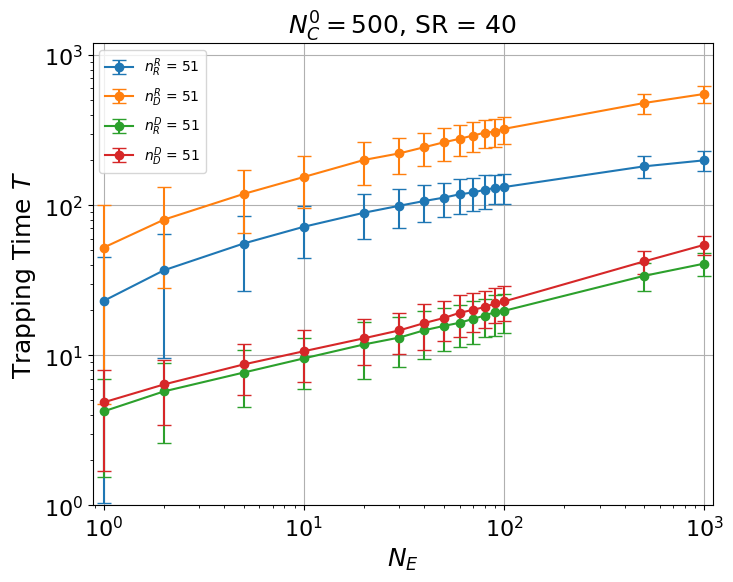

In [67]:
dfs_list =[
[
df_NP01_NH500_TCC_005_TCT_005_O_51_SR40, 
df_NP02_NH500_TCC_005_TCT_005_O_51_SR40, 
df_NP05_NH500_TCC_005_TCT_005_O_51_SR40, 
df_NP10_NH500_TCC_005_TCT_005_O_51_SR40,
df_NP20_NH500_TCC_005_TCT_005_O_51_SR40, 
df_NP30_NH500_TCC_005_TCT_005_O_51_SR40, 
df_NP40_NH500_TCC_005_TCT_005_O_51_SR40, 
df_NP50_NH500_TCC_005_TCT_005_O_51_SR40,
df_NP60_NH500_TCC_005_TCT_005_O_51_SR40, 
df_NP70_NH500_TCC_005_TCT_005_O_51_SR40, 
df_NP80_NH500_TCC_005_TCT_005_O_51_SR40, 
df_NP90_NH500_TCC_005_TCT_005_O_51_SR40,
df_NP100_NH500_TCC_005_TCT_005_O_51_SR40, 
df_NP500_NH500_TCC_005_TCT_005_O_51_SR40,
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR40
], 
[
df_NP01_NH500_TCC_095_TCT_005_O_51_SR40, 
df_NP02_NH500_TCC_095_TCT_005_O_51_SR40, 
df_NP05_NH500_TCC_095_TCT_005_O_51_SR40, 
df_NP10_NH500_TCC_095_TCT_005_O_51_SR40,
df_NP20_NH500_TCC_095_TCT_005_O_51_SR40, 
df_NP30_NH500_TCC_095_TCT_005_O_51_SR40, 
df_NP40_NH500_TCC_095_TCT_005_O_51_SR40, 
df_NP50_NH500_TCC_095_TCT_005_O_51_SR40,
df_NP60_NH500_TCC_095_TCT_005_O_51_SR40, 
df_NP70_NH500_TCC_095_TCT_005_O_51_SR40, 
df_NP80_NH500_TCC_095_TCT_005_O_51_SR40, 
df_NP90_NH500_TCC_095_TCT_005_O_51_SR40,
df_NP100_NH500_TCC_095_TCT_005_O_51_SR40, 
df_NP500_NH500_TCC_095_TCT_005_O_51_SR40,
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR40
], 
[
df_NP01_NH500_TCC_005_TCT_095_O_51_SR40, 
df_NP02_NH500_TCC_005_TCT_095_O_51_SR40, 
df_NP05_NH500_TCC_005_TCT_095_O_51_SR40, 
df_NP10_NH500_TCC_005_TCT_095_O_51_SR40,
df_NP20_NH500_TCC_005_TCT_095_O_51_SR40, 
df_NP30_NH500_TCC_005_TCT_095_O_51_SR40, 
df_NP40_NH500_TCC_005_TCT_095_O_51_SR40, 
df_NP50_NH500_TCC_005_TCT_095_O_51_SR40,
df_NP60_NH500_TCC_005_TCT_095_O_51_SR40, 
df_NP70_NH500_TCC_005_TCT_095_O_51_SR40, 
df_NP80_NH500_TCC_005_TCT_095_O_51_SR40, 
df_NP90_NH500_TCC_005_TCT_095_O_51_SR40,
df_NP100_NH500_TCC_005_TCT_095_O_51_SR40, 
df_NP500_NH500_TCC_005_TCT_095_O_51_SR40,
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR40
], 

[
df_NP01_NH500_TCC_095_TCT_095_O_51_SR40, 
df_NP02_NH500_TCC_095_TCT_095_O_51_SR40, 
df_NP05_NH500_TCC_095_TCT_095_O_51_SR40, 
df_NP10_NH500_TCC_095_TCT_095_O_51_SR40,
df_NP20_NH500_TCC_095_TCT_095_O_51_SR40, 
df_NP30_NH500_TCC_095_TCT_095_O_51_SR40, 
df_NP40_NH500_TCC_095_TCT_095_O_51_SR40, 
df_NP50_NH500_TCC_095_TCT_095_O_51_SR40,
df_NP60_NH500_TCC_095_TCT_095_O_51_SR40, 
df_NP70_NH500_TCC_095_TCT_095_O_51_SR40, 
df_NP80_NH500_TCC_095_TCT_095_O_51_SR40, 
df_NP90_NH500_TCC_095_TCT_095_O_51_SR40,
df_NP100_NH500_TCC_095_TCT_095_O_51_SR40, 
df_NP500_NH500_TCC_095_TCT_095_O_51_SR40,
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR40
]
]

nc_values = [
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.0
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.02
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],   # Valores de NC para O = 0.05
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000]
]

labels =[
        #Para o caso 0.05
        "$n_{R}^{R}$ = 51","$n_{D}^{R}$ = 51",
        "$n_{R}^{D}$ = 51","$n_{D}^{D}$ = 51"
        ]

plotar_media_steps_com_erro(
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, SR = 40", 
    xlabel="$N_{E}$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=8.8e-1, x_max=1.1e3, 
    y_min=1e0, y_max=1200, 
    #save_path="trap_x_n_prey_CTN_050_CCN_050_SR_5_O_v.png")
    save_path="trap_x_n_prey_TCC_both_TCT_both_SR_40_O_51.pdf")

### SR = 50, n = 0.

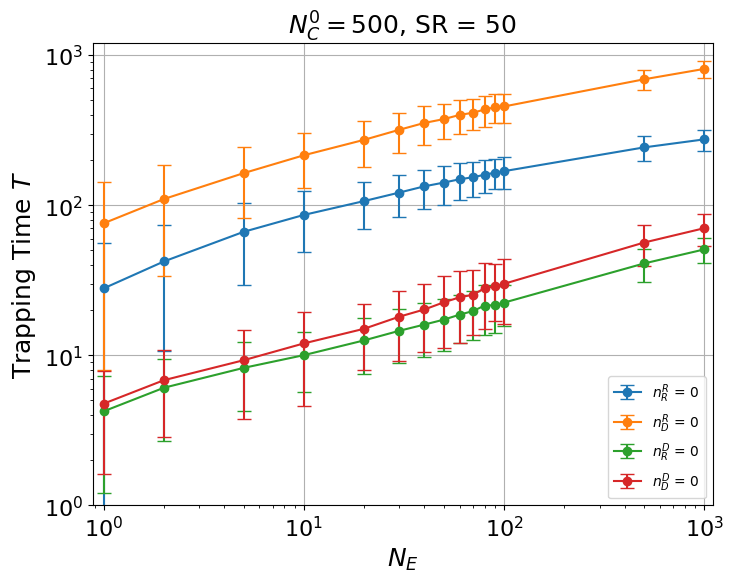

In [68]:
dfs_list =[
[
df_NP01_NH500_TCC_005_TCT_005_O_00_SR50, 
df_NP02_NH500_TCC_005_TCT_005_O_00_SR50, 
df_NP05_NH500_TCC_005_TCT_005_O_00_SR50, 
df_NP10_NH500_TCC_005_TCT_005_O_00_SR50,
df_NP20_NH500_TCC_005_TCT_005_O_00_SR50, 
df_NP30_NH500_TCC_005_TCT_005_O_00_SR50, 
df_NP40_NH500_TCC_005_TCT_005_O_00_SR50, 
df_NP50_NH500_TCC_005_TCT_005_O_00_SR50,
df_NP60_NH500_TCC_005_TCT_005_O_00_SR50, 
df_NP70_NH500_TCC_005_TCT_005_O_00_SR50, 
df_NP80_NH500_TCC_005_TCT_005_O_00_SR50, 
df_NP90_NH500_TCC_005_TCT_005_O_00_SR50,
df_NP100_NH500_TCC_005_TCT_005_O_00_SR50, 
df_NP500_NH500_TCC_005_TCT_005_O_00_SR50,
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR50
], 
[
df_NP01_NH500_TCC_095_TCT_005_O_00_SR50, 
df_NP02_NH500_TCC_095_TCT_005_O_00_SR50, 
df_NP05_NH500_TCC_095_TCT_005_O_00_SR50, 
df_NP10_NH500_TCC_095_TCT_005_O_00_SR50,
df_NP20_NH500_TCC_095_TCT_005_O_00_SR50, 
df_NP30_NH500_TCC_095_TCT_005_O_00_SR50, 
df_NP40_NH500_TCC_095_TCT_005_O_00_SR50, 
df_NP50_NH500_TCC_095_TCT_005_O_00_SR50,
df_NP60_NH500_TCC_095_TCT_005_O_00_SR50, 
df_NP70_NH500_TCC_095_TCT_005_O_00_SR50, 
df_NP80_NH500_TCC_095_TCT_005_O_00_SR50, 
df_NP90_NH500_TCC_095_TCT_005_O_00_SR50,
df_NP100_NH500_TCC_095_TCT_005_O_00_SR50, 
df_NP500_NH500_TCC_095_TCT_005_O_00_SR50,
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR50
], 
[
df_NP01_NH500_TCC_005_TCT_095_O_00_SR50, 
df_NP02_NH500_TCC_005_TCT_095_O_00_SR50, 
df_NP05_NH500_TCC_005_TCT_095_O_00_SR50, 
df_NP10_NH500_TCC_005_TCT_095_O_00_SR50,
df_NP20_NH500_TCC_005_TCT_095_O_00_SR50, 
df_NP30_NH500_TCC_005_TCT_095_O_00_SR50, 
df_NP40_NH500_TCC_005_TCT_095_O_00_SR50, 
df_NP50_NH500_TCC_005_TCT_095_O_00_SR50,
df_NP60_NH500_TCC_005_TCT_095_O_00_SR50, 
df_NP70_NH500_TCC_005_TCT_095_O_00_SR50, 
df_NP80_NH500_TCC_005_TCT_095_O_00_SR50, 
df_NP90_NH500_TCC_005_TCT_095_O_00_SR50,
df_NP100_NH500_TCC_005_TCT_095_O_00_SR50, 
df_NP500_NH500_TCC_005_TCT_095_O_00_SR50,
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR50
], 

[
df_NP01_NH500_TCC_095_TCT_095_O_00_SR50, 
df_NP02_NH500_TCC_095_TCT_095_O_00_SR50, 
df_NP05_NH500_TCC_095_TCT_095_O_00_SR50, 
df_NP10_NH500_TCC_095_TCT_095_O_00_SR50,
df_NP20_NH500_TCC_095_TCT_095_O_00_SR50, 
df_NP30_NH500_TCC_095_TCT_095_O_00_SR50, 
df_NP40_NH500_TCC_095_TCT_095_O_00_SR50, 
df_NP50_NH500_TCC_095_TCT_095_O_00_SR50,
df_NP60_NH500_TCC_095_TCT_095_O_00_SR50, 
df_NP70_NH500_TCC_095_TCT_095_O_00_SR50, 
df_NP80_NH500_TCC_095_TCT_095_O_00_SR50, 
df_NP90_NH500_TCC_095_TCT_095_O_00_SR50,
df_NP100_NH500_TCC_095_TCT_095_O_00_SR50, 
df_NP500_NH500_TCC_095_TCT_095_O_00_SR50,
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR50
]
]

nc_values = [
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.0
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.02
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],   # Valores de NC para O = 0.05
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000]
]

labels =[
        #Para o caso 0.05
        "$n_{R}^{R}$ = 0","$n_{D}^{R}$ = 0",
        "$n_{R}^{D}$ = 0","$n_{D}^{D}$ = 0"
        ]

plotar_media_steps_com_erro(
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, SR = 50", 
    xlabel="$N_{E}$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=8.8e-1, x_max=1.1e3, 
    y_min=1e0, y_max=1200, 
    #save_path="trap_x_n_prey_CTN_050_CCN_050_SR_5_O_v.png")
    save_path="trap_x_n_prey_TCC_both_TCT_both_SR_50_O_0.pdf")

### SR = 50, n = 51.

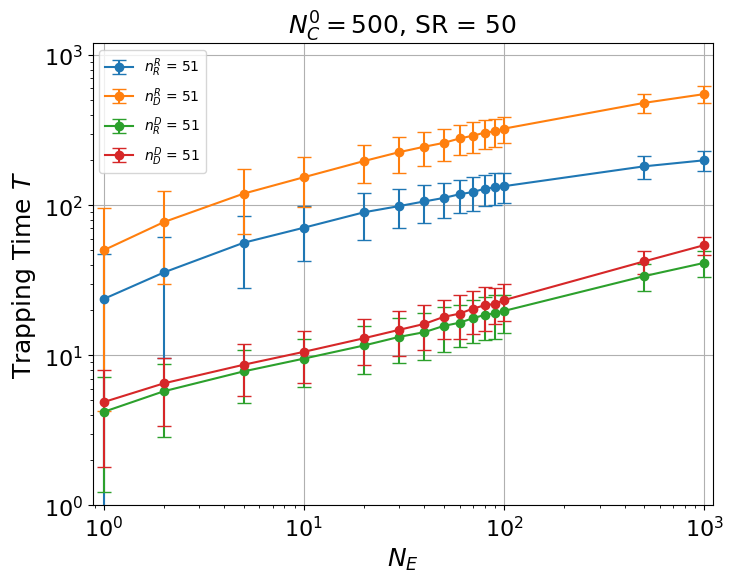

In [69]:
dfs_list =[
[
df_NP01_NH500_TCC_005_TCT_005_O_51_SR50, 
df_NP02_NH500_TCC_005_TCT_005_O_51_SR50, 
df_NP05_NH500_TCC_005_TCT_005_O_51_SR50, 
df_NP10_NH500_TCC_005_TCT_005_O_51_SR50,
df_NP20_NH500_TCC_005_TCT_005_O_51_SR50, 
df_NP30_NH500_TCC_005_TCT_005_O_51_SR50, 
df_NP40_NH500_TCC_005_TCT_005_O_51_SR50, 
df_NP50_NH500_TCC_005_TCT_005_O_51_SR50,
df_NP60_NH500_TCC_005_TCT_005_O_51_SR50, 
df_NP70_NH500_TCC_005_TCT_005_O_51_SR50, 
df_NP80_NH500_TCC_005_TCT_005_O_51_SR50, 
df_NP90_NH500_TCC_005_TCT_005_O_51_SR50,
df_NP100_NH500_TCC_005_TCT_005_O_51_SR50, 
df_NP500_NH500_TCC_005_TCT_005_O_51_SR50,
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR50
], 
[
df_NP01_NH500_TCC_095_TCT_005_O_51_SR50, 
df_NP02_NH500_TCC_095_TCT_005_O_51_SR50, 
df_NP05_NH500_TCC_095_TCT_005_O_51_SR50, 
df_NP10_NH500_TCC_095_TCT_005_O_51_SR50,
df_NP20_NH500_TCC_095_TCT_005_O_51_SR50, 
df_NP30_NH500_TCC_095_TCT_005_O_51_SR50, 
df_NP40_NH500_TCC_095_TCT_005_O_51_SR50, 
df_NP50_NH500_TCC_095_TCT_005_O_51_SR50,
df_NP60_NH500_TCC_095_TCT_005_O_51_SR50, 
df_NP70_NH500_TCC_095_TCT_005_O_51_SR50, 
df_NP80_NH500_TCC_095_TCT_005_O_51_SR50, 
df_NP90_NH500_TCC_095_TCT_005_O_51_SR50,
df_NP100_NH500_TCC_095_TCT_005_O_51_SR50, 
df_NP500_NH500_TCC_095_TCT_005_O_51_SR50,
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR50
], 
[
df_NP01_NH500_TCC_005_TCT_095_O_51_SR50, 
df_NP02_NH500_TCC_005_TCT_095_O_51_SR50, 
df_NP05_NH500_TCC_005_TCT_095_O_51_SR50, 
df_NP10_NH500_TCC_005_TCT_095_O_51_SR50,
df_NP20_NH500_TCC_005_TCT_095_O_51_SR50, 
df_NP30_NH500_TCC_005_TCT_095_O_51_SR50, 
df_NP40_NH500_TCC_005_TCT_095_O_51_SR50, 
df_NP50_NH500_TCC_005_TCT_095_O_51_SR50,
df_NP60_NH500_TCC_005_TCT_095_O_51_SR50, 
df_NP70_NH500_TCC_005_TCT_095_O_51_SR50, 
df_NP80_NH500_TCC_005_TCT_095_O_51_SR50, 
df_NP90_NH500_TCC_005_TCT_095_O_51_SR50,
df_NP100_NH500_TCC_005_TCT_095_O_51_SR50, 
df_NP500_NH500_TCC_005_TCT_095_O_51_SR50,
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR50
], 

[
df_NP01_NH500_TCC_095_TCT_095_O_51_SR50, 
df_NP02_NH500_TCC_095_TCT_095_O_51_SR50, 
df_NP05_NH500_TCC_095_TCT_095_O_51_SR50, 
df_NP10_NH500_TCC_095_TCT_095_O_51_SR50,
df_NP20_NH500_TCC_095_TCT_095_O_51_SR50, 
df_NP30_NH500_TCC_095_TCT_095_O_51_SR50, 
df_NP40_NH500_TCC_095_TCT_095_O_51_SR50, 
df_NP50_NH500_TCC_095_TCT_095_O_51_SR50,
df_NP60_NH500_TCC_095_TCT_095_O_51_SR50, 
df_NP70_NH500_TCC_095_TCT_095_O_51_SR50, 
df_NP80_NH500_TCC_095_TCT_095_O_51_SR50, 
df_NP90_NH500_TCC_095_TCT_095_O_51_SR50,
df_NP100_NH500_TCC_095_TCT_095_O_51_SR50, 
df_NP500_NH500_TCC_095_TCT_095_O_51_SR50,
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR50
]
]

nc_values = [
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.0
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.02
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],   # Valores de NC para O = 0.05
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000]
]

labels =[
        #Para o caso 0.05
        "$n_{R}^{R}$ = 51","$n_{D}^{R}$ = 51",
        "$n_{R}^{D}$ = 51","$n_{D}^{D}$ = 51"
        ]

plotar_media_steps_com_erro(
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, SR = 50", 
    xlabel="$N_{E}$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=8.8e-1, x_max=1.1e3, 
    y_min=1e0, y_max=1200, 
    #save_path="trap_x_n_prey_CTN_050_CCN_050_SR_5_O_v.png")
    save_path="trap_x_n_prey_TCC_both_TCT_both_SR_50_O_51.pdf")

### Teste cruzados

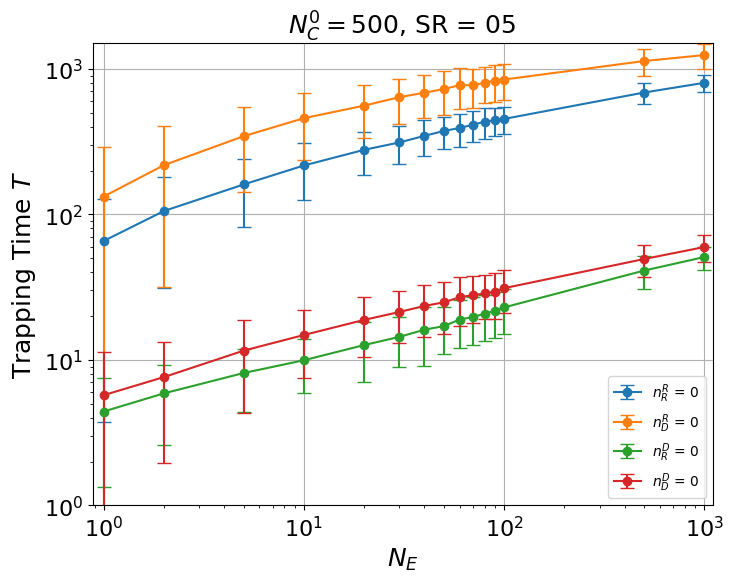

In [81]:
dfs_list =[
[
df_NP01_NH500_TCC_095_SR05_TCT_005_SR50_O_00,
df_NP02_NH500_TCC_095_SR05_TCT_005_SR50_O_00, 
df_NP05_NH500_TCC_095_SR05_TCT_005_SR50_O_00, 
df_NP10_NH500_TCC_095_SR05_TCT_005_SR50_O_00, 
df_NP20_NH500_TCC_095_SR05_TCT_005_SR50_O_00, 
df_NP30_NH500_TCC_095_SR05_TCT_005_SR50_O_00,
df_NP40_NH500_TCC_095_SR05_TCT_005_SR50_O_00,
df_NP50_NH500_TCC_095_SR05_TCT_005_SR50_O_00,
df_NP60_NH500_TCC_095_SR05_TCT_005_SR50_O_00,
df_NP70_NH500_TCC_095_SR05_TCT_005_SR50_O_00, 
df_NP80_NH500_TCC_095_SR05_TCT_005_SR50_O_00, 
df_NP90_NH500_TCC_095_SR05_TCT_005_SR50_O_00, 
df_NP100_NH500_TCC_095_SR05_TCT_005_SR50_O_00,
df_NP500_NH500_TCC_095_SR05_TCT_005_SR50_O_00,
df_NP1000_NH500_TCC_095_SR05_TCT_005_SR50_O_00
], 
[
df_NP01_NH500_TCC_095_SR50_TCT_005_SR05_O_00,
df_NP02_NH500_TCC_095_SR50_TCT_005_SR05_O_00, 
df_NP05_NH500_TCC_095_SR50_TCT_005_SR05_O_00, 
df_NP10_NH500_TCC_095_SR50_TCT_005_SR05_O_00, 
df_NP20_NH500_TCC_095_SR50_TCT_005_SR05_O_00, 
df_NP30_NH500_TCC_095_SR50_TCT_005_SR05_O_00,
df_NP40_NH500_TCC_095_SR50_TCT_005_SR05_O_00,
df_NP50_NH500_TCC_095_SR50_TCT_005_SR05_O_00,
df_NP60_NH500_TCC_095_SR50_TCT_005_SR05_O_00,
df_NP70_NH500_TCC_095_SR50_TCT_005_SR05_O_00, 
df_NP80_NH500_TCC_095_SR50_TCT_005_SR05_O_00, 
df_NP90_NH500_TCC_095_SR50_TCT_005_SR05_O_00, 
df_NP100_NH500_TCC_095_SR50_TCT_005_SR05_O_00,
df_NP500_NH500_TCC_095_SR50_TCT_005_SR05_O_00,
df_NP1000_NH500_TCC_095_SR50_TCT_005_SR05_O_00
], 
[
df_NP01_NH500_TCC_005_SR05_TCT_095_SR50_O_00,
df_NP02_NH500_TCC_005_SR05_TCT_095_SR50_O_00, 
df_NP05_NH500_TCC_005_SR05_TCT_095_SR50_O_00, 
df_NP10_NH500_TCC_005_SR05_TCT_095_SR50_O_00, 
df_NP20_NH500_TCC_005_SR05_TCT_095_SR50_O_00, 
df_NP30_NH500_TCC_005_SR05_TCT_095_SR50_O_00,
df_NP40_NH500_TCC_005_SR05_TCT_095_SR50_O_00,
df_NP50_NH500_TCC_005_SR05_TCT_095_SR50_O_00,
df_NP60_NH500_TCC_005_SR05_TCT_095_SR50_O_00,
df_NP70_NH500_TCC_005_SR05_TCT_095_SR50_O_00, 
df_NP80_NH500_TCC_005_SR05_TCT_095_SR50_O_00, 
df_NP90_NH500_TCC_005_SR05_TCT_095_SR50_O_00, 
df_NP100_NH500_TCC_005_SR05_TCT_095_SR50_O_00,
df_NP500_NH500_TCC_005_SR05_TCT_095_SR50_O_00,
df_NP1000_NH500_TCC_005_SR05_TCT_095_SR50_O_00
], 

[
df_NP01_NH500_TCC_005_SR50_TCT_095_SR05_O_00,
df_NP02_NH500_TCC_005_SR50_TCT_095_SR05_O_00, 
df_NP05_NH500_TCC_005_SR50_TCT_095_SR05_O_00, 
df_NP10_NH500_TCC_005_SR50_TCT_095_SR05_O_00, 
df_NP20_NH500_TCC_005_SR50_TCT_095_SR05_O_00, 
df_NP30_NH500_TCC_005_SR50_TCT_095_SR05_O_00,
df_NP40_NH500_TCC_005_SR50_TCT_095_SR05_O_00,
df_NP50_NH500_TCC_005_SR50_TCT_095_SR05_O_00,
df_NP60_NH500_TCC_005_SR50_TCT_095_SR05_O_00,
df_NP70_NH500_TCC_005_SR50_TCT_095_SR05_O_00, 
df_NP80_NH500_TCC_005_SR50_TCT_095_SR05_O_00, 
df_NP90_NH500_TCC_005_SR50_TCT_095_SR05_O_00, 
df_NP100_NH500_TCC_005_SR50_TCT_095_SR05_O_00,
df_NP500_NH500_TCC_005_SR50_TCT_095_SR05_O_00,
df_NP1000_NH500_TCC_005_SR50_TCT_095_SR05_O_00
]
]

nc_values = [
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.0
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.02
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],   # Valores de NC para O = 0.05
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000]
]

labels =[
        #Para o caso 0.05
        "$n_{R}^{R}$ = 0", "$n_{D}^{R}$ = 0",
        "$n_{R}^{D}$ = 0","$n_{D}^{D}$ = 0"
        ]

plotar_media_steps_com_erro(
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, SR = 05", 
    xlabel="$N_{E}$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=8.8e-1, x_max=1.1e3, 
    y_min=1e0, y_max=1500, 
    #save_path="trap_x_n_prey_CTN_050_CCN_050_SR_5_O_v.png")
    save_path="trap_x_n_prey_TCC_both_TCT_both_SR_5_O_0.pdf")

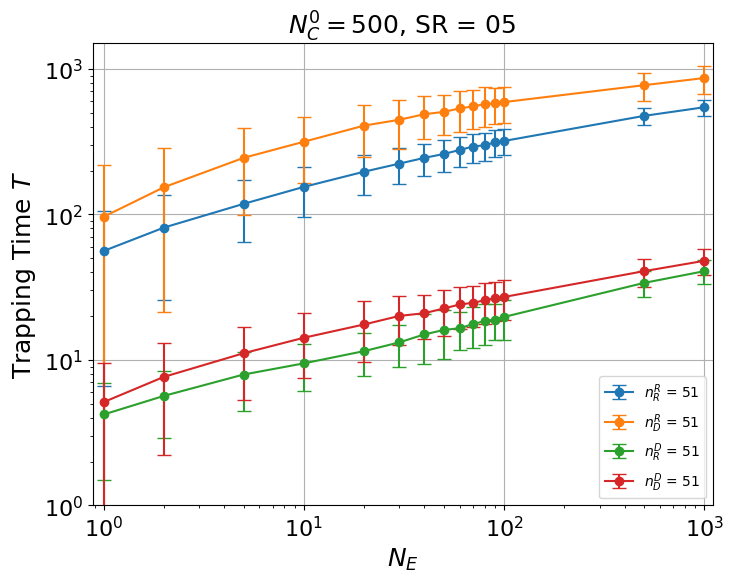

In [82]:
dfs_list =[
[
df_NP01_NH500_TCC_095_SR05_TCT_005_SR50_O_51,
df_NP02_NH500_TCC_095_SR05_TCT_005_SR50_O_51, 
df_NP05_NH500_TCC_095_SR05_TCT_005_SR50_O_51, 
df_NP10_NH500_TCC_095_SR05_TCT_005_SR50_O_51, 
df_NP20_NH500_TCC_095_SR05_TCT_005_SR50_O_51, 
df_NP30_NH500_TCC_095_SR05_TCT_005_SR50_O_51,
df_NP40_NH500_TCC_095_SR05_TCT_005_SR50_O_51,
df_NP50_NH500_TCC_095_SR05_TCT_005_SR50_O_51,
df_NP60_NH500_TCC_095_SR05_TCT_005_SR50_O_51,
df_NP70_NH500_TCC_095_SR05_TCT_005_SR50_O_51, 
df_NP80_NH500_TCC_095_SR05_TCT_005_SR50_O_51, 
df_NP90_NH500_TCC_095_SR05_TCT_005_SR50_O_51, 
df_NP100_NH500_TCC_095_SR05_TCT_005_SR50_O_51,
df_NP500_NH500_TCC_095_SR05_TCT_005_SR50_O_51,
df_NP1000_NH500_TCC_095_SR05_TCT_005_SR50_O_51
], 
[
df_NP01_NH500_TCC_095_SR50_TCT_005_SR05_O_51,
df_NP02_NH500_TCC_095_SR50_TCT_005_SR05_O_51, 
df_NP05_NH500_TCC_095_SR50_TCT_005_SR05_O_51, 
df_NP10_NH500_TCC_095_SR50_TCT_005_SR05_O_51, 
df_NP20_NH500_TCC_095_SR50_TCT_005_SR05_O_51, 
df_NP30_NH500_TCC_095_SR50_TCT_005_SR05_O_51,
df_NP40_NH500_TCC_095_SR50_TCT_005_SR05_O_51,
df_NP50_NH500_TCC_095_SR50_TCT_005_SR05_O_51,
df_NP60_NH500_TCC_095_SR50_TCT_005_SR05_O_51,
df_NP70_NH500_TCC_095_SR50_TCT_005_SR05_O_51, 
df_NP80_NH500_TCC_095_SR50_TCT_005_SR05_O_51, 
df_NP90_NH500_TCC_095_SR50_TCT_005_SR05_O_51, 
df_NP100_NH500_TCC_095_SR50_TCT_005_SR05_O_51,
df_NP500_NH500_TCC_095_SR50_TCT_005_SR05_O_51,
df_NP1000_NH500_TCC_095_SR50_TCT_005_SR05_O_51
], 
[
df_NP01_NH500_TCC_005_SR05_TCT_095_SR50_O_51,
df_NP02_NH500_TCC_005_SR05_TCT_095_SR50_O_51, 
df_NP05_NH500_TCC_005_SR05_TCT_095_SR50_O_51, 
df_NP10_NH500_TCC_005_SR05_TCT_095_SR50_O_51, 
df_NP20_NH500_TCC_005_SR05_TCT_095_SR50_O_51, 
df_NP30_NH500_TCC_005_SR05_TCT_095_SR50_O_51,
df_NP40_NH500_TCC_005_SR05_TCT_095_SR50_O_51,
df_NP50_NH500_TCC_005_SR05_TCT_095_SR50_O_51,
df_NP60_NH500_TCC_005_SR05_TCT_095_SR50_O_51,
df_NP70_NH500_TCC_005_SR05_TCT_095_SR50_O_51, 
df_NP80_NH500_TCC_005_SR05_TCT_095_SR50_O_51, 
df_NP90_NH500_TCC_005_SR05_TCT_095_SR50_O_51, 
df_NP100_NH500_TCC_005_SR05_TCT_095_SR50_O_51,
df_NP500_NH500_TCC_005_SR05_TCT_095_SR50_O_51,
df_NP1000_NH500_TCC_005_SR05_TCT_095_SR50_O_51
], 

[
df_NP01_NH500_TCC_005_SR50_TCT_095_SR05_O_51,
df_NP02_NH500_TCC_005_SR50_TCT_095_SR05_O_51, 
df_NP05_NH500_TCC_005_SR50_TCT_095_SR05_O_51, 
df_NP10_NH500_TCC_005_SR50_TCT_095_SR05_O_51, 
df_NP20_NH500_TCC_005_SR50_TCT_095_SR05_O_51, 
df_NP30_NH500_TCC_005_SR50_TCT_095_SR05_O_51,
df_NP40_NH500_TCC_005_SR50_TCT_095_SR05_O_51,
df_NP50_NH500_TCC_005_SR50_TCT_095_SR05_O_51,
df_NP60_NH500_TCC_005_SR50_TCT_095_SR05_O_51,
df_NP70_NH500_TCC_005_SR50_TCT_095_SR05_O_51, 
df_NP80_NH500_TCC_005_SR50_TCT_095_SR05_O_51, 
df_NP90_NH500_TCC_005_SR50_TCT_095_SR05_O_51, 
df_NP100_NH500_TCC_005_SR50_TCT_095_SR05_O_51,
df_NP500_NH500_TCC_005_SR50_TCT_095_SR05_O_51,
df_NP1000_NH500_TCC_005_SR50_TCT_095_SR05_O_51
]
]

nc_values = [
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.0
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],  # Valores de NC para O = 0.02
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000],   # Valores de NC para O = 0.05
    [1, 2, 5,10,20,30,40,50,60,70,80,90,100,500,1000]
]

labels =[
        #Para o caso 0.05
        "$n_{R}^{R}$ = 51", "$n_{D}^{R}$ = 51",
        "$n_{R}^{D}$ = 51","$n_{D}^{D}$ = 51"
        ]

plotar_media_steps_com_erro(
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, SR = 05", 
    xlabel="$N_{E}$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=8.8e-1, x_max=1.1e3, 
    y_min=1e0, y_max=1500, 
    #save_path="trap_x_n_prey_CTN_050_CCN_050_SR_5_O_v.png")
    save_path="trap_x_n_prey_TCC_both_TCT_both_SR_5_O_51.pdf")